## Per questi plot è stato usato il dataset native

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'retina'

native_df = pd.read_csv('output_files/native/native.csv')
decoys_df = pd.read_csv('output_files/decoys/decoys.csv')
all_native_df = pd.read_csv('output_files/native/all_native.csv')

def add_ring_mean_columns(df, radius_col='radius', n_rings=10):
    for ring_id in range(1, n_rings + 1):
        # Valore medio del raggio dell'anello in Angstrom
        df[f'ring{ring_id}_mean_A'] = df[radius_col] * (ring_id - 0.5) / 10
    return df

native_df = add_ring_mean_columns(native_df)
decoys_df = add_ring_mean_columns(decoys_df)
all_native_df = add_ring_mean_columns(all_native_df)

native_labeled = native_df.copy()
native_labeled['dataset_label'] = 'native'

decoys_labeled = decoys_df.copy()
decoys_labeled['complex_name'] = decoys_labeled['complex_name'].astype(str).str.split('-').str[0].str[:4]
decoys_labeled['dataset_label'] = 'decoy'

tot_df = pd.concat([native_labeled, decoys_labeled], ignore_index=True)

rings = [f'ring{n}_mean_A' for n in range(1, 11)]
zernike = [f'zernike_ring{n}_mean' for n in range(1, 11)]
zernike_sigma = [f'zernike_ring{n}_uncertainty' for n in range(1, 11)]
physical = [f'physical_ring{n}_mean' for n in range(1, 11)]
physical_sigma = [f'physical_ring{n}_uncertainty' for n in range(1, 11)]
roughness = [f'roughness_ring{n}' for n in range(1, 11)]

print('native_df:', native_df.shape)
print('decoys_df:', decoys_df.shape)
print('all_native_df:', all_native_df.shape)
print('tot_df:', tot_df.shape)

native_df: (3134, 73)
decoys_df: (3134, 73)
all_native_df: (3731, 73)
tot_df: (6268, 74)


In [2]:
import matplotlib.patches as mpatches


def build_rdf_long_df(df, metric_cols, dataset_label, radius_col='radius', n_rings=10, max_radius=50.0, bin_width=2.0):
    records = []
    n_bins = int(max_radius / bin_width)

    for _, row in df.iterrows():
        radius = pd.to_numeric(row.get(radius_col), errors='coerce')
        if not np.isfinite(radius) or radius <= 0:
            continue

        for ring_id in range(1, n_rings + 1):
            metric_value = pd.to_numeric(row.get(metric_cols[ring_id - 1]), errors='coerce')
            if not np.isfinite(metric_value):
                continue

            ring_radius = float(radius) * (ring_id - 0.5) / n_rings
            if not np.isfinite(ring_radius) or ring_radius < 0 or ring_radius > max_radius:
                continue

            bin_id = min(int(ring_radius // bin_width) + 1, n_bins)
            records.append({
                'dataset_label': dataset_label,
                'ring_id': ring_id,
                'rdf_value': float(metric_value),
                'ring_radius_A': ring_radius,
                'radius_bin_id': bin_id,
                'radius_bin_center_A': bin_id * bin_width - bin_width / 2.0,
            })

    return pd.DataFrame.from_records(records)


palette = {'native': '#1f77b4', 'decoy': '#d62728'}

physical_plot_df = pd.concat([
    build_rdf_long_df(native_df, physical, 'native'),
    build_rdf_long_df(decoys_df, physical, 'decoy'),
] , ignore_index=True)
zernike_plot_df = pd.concat([
    build_rdf_long_df(native_df, zernike, 'native'),
    build_rdf_long_df(decoys_df, zernike, 'decoy'),
] , ignore_index=True)
roughness_plot_df = pd.concat([
    build_rdf_long_df(native_df, roughness, 'native'),
    build_rdf_long_df(decoys_df, roughness, 'decoy'),
] , ignore_index=True)

print('physical_plot_df:', physical_plot_df.shape)
print('zernike_plot_df:', zernike_plot_df.shape)
print('roughness_plot_df:', roughness_plot_df.shape)

physical_plot_df: (62136, 6)
zernike_plot_df: (62136, 6)
roughness_plot_df: (62136, 6)


# Radial distribution functions
Entrambe sono crescenti, quindi al centro del binding site le due proteine tendono ad essere più vicine e a massimizzare la complementarità di forma

Distanza physical sembra avere andamento esponenziale, distanza zernike andamento lineare
In zernike l'ultimo anello ha una diminuzione ma potrebbe essere perché allontanandoci dal centro i residui sono poco interagenti (infatti la distanza fisica è alta) e quindi la superficie di van der waals diventano più piatte.

Se si guarda la distanza radiale in Å la complementarità di forma sembra saturare a circa 20 Å

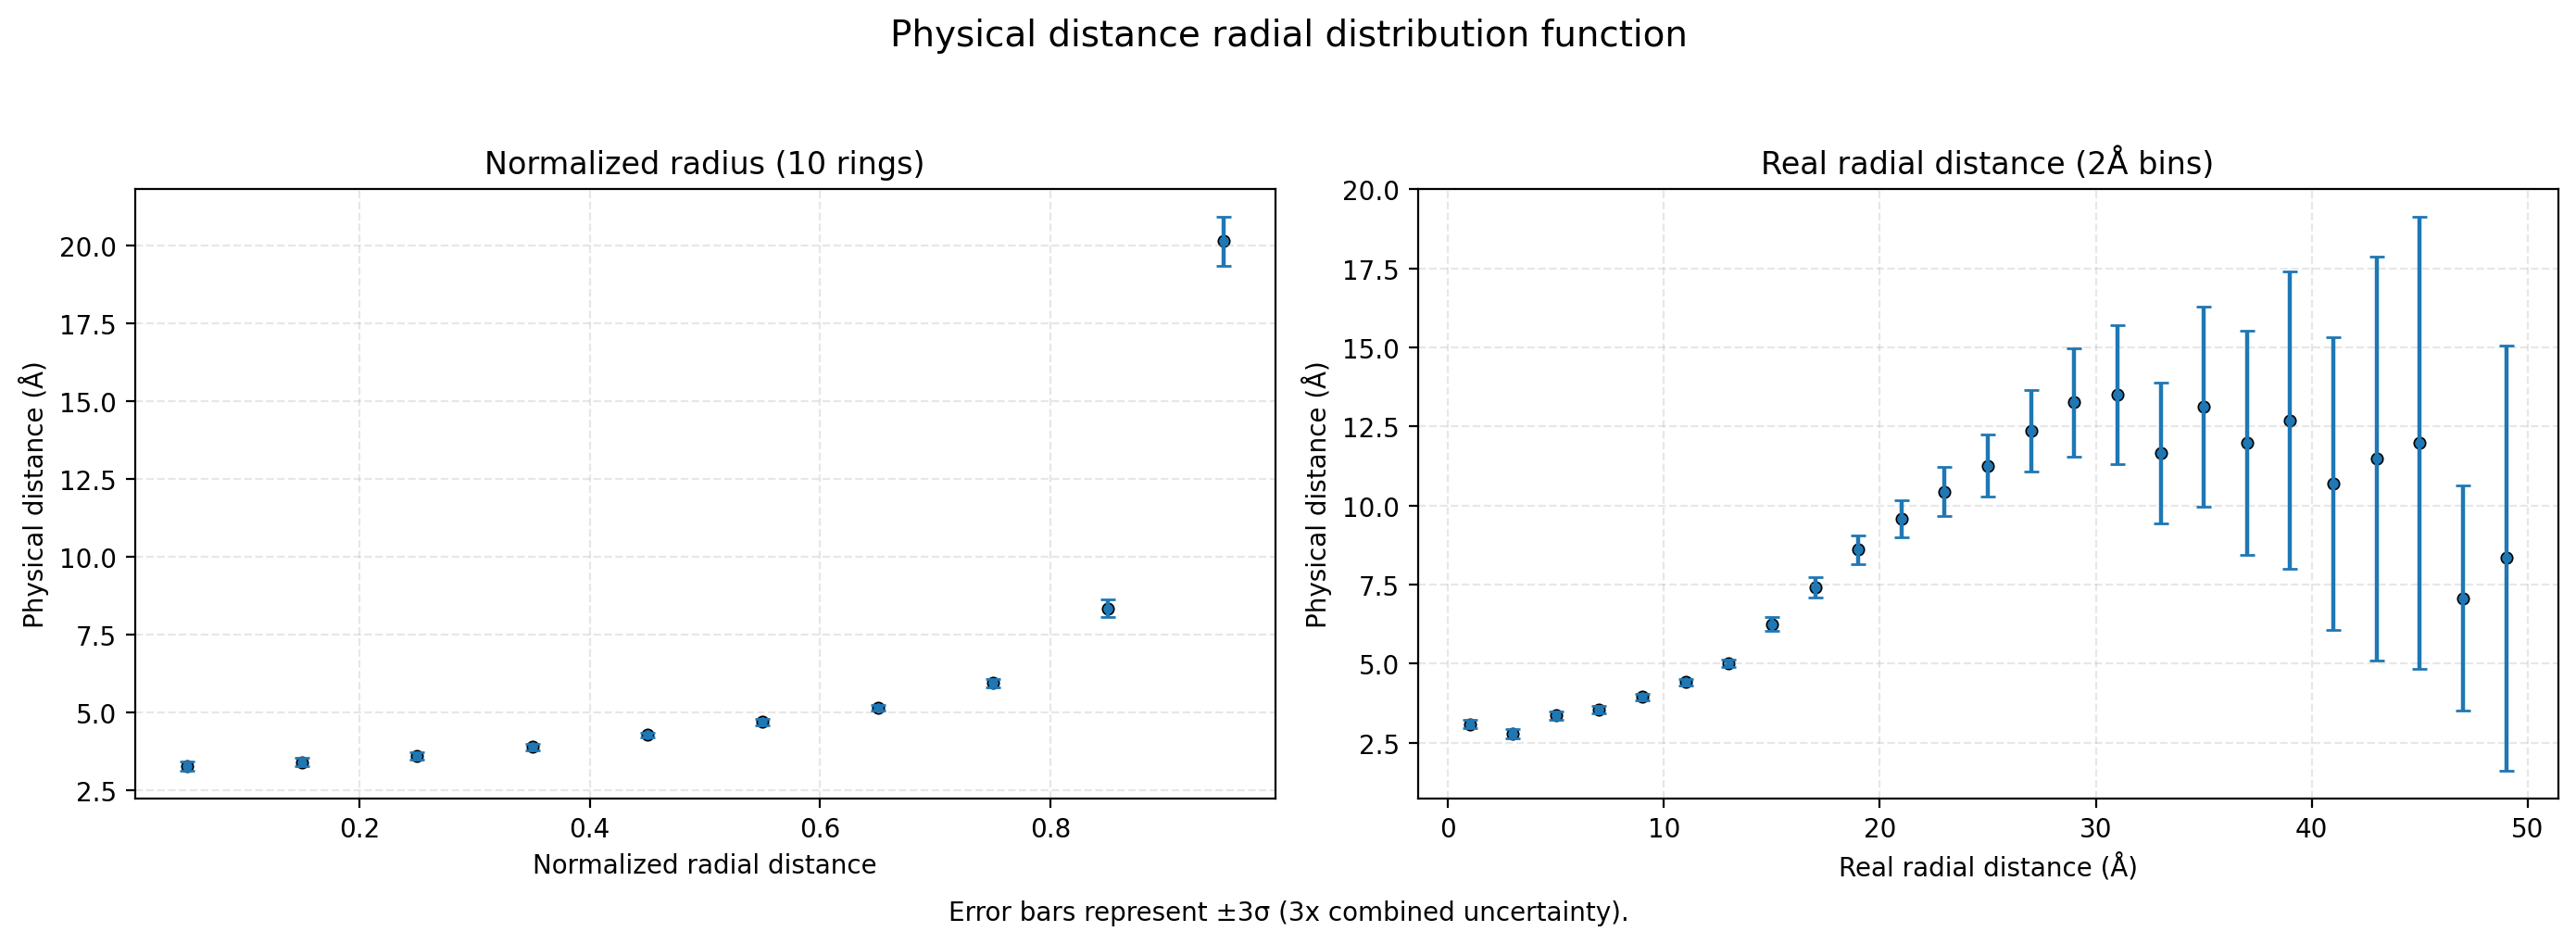

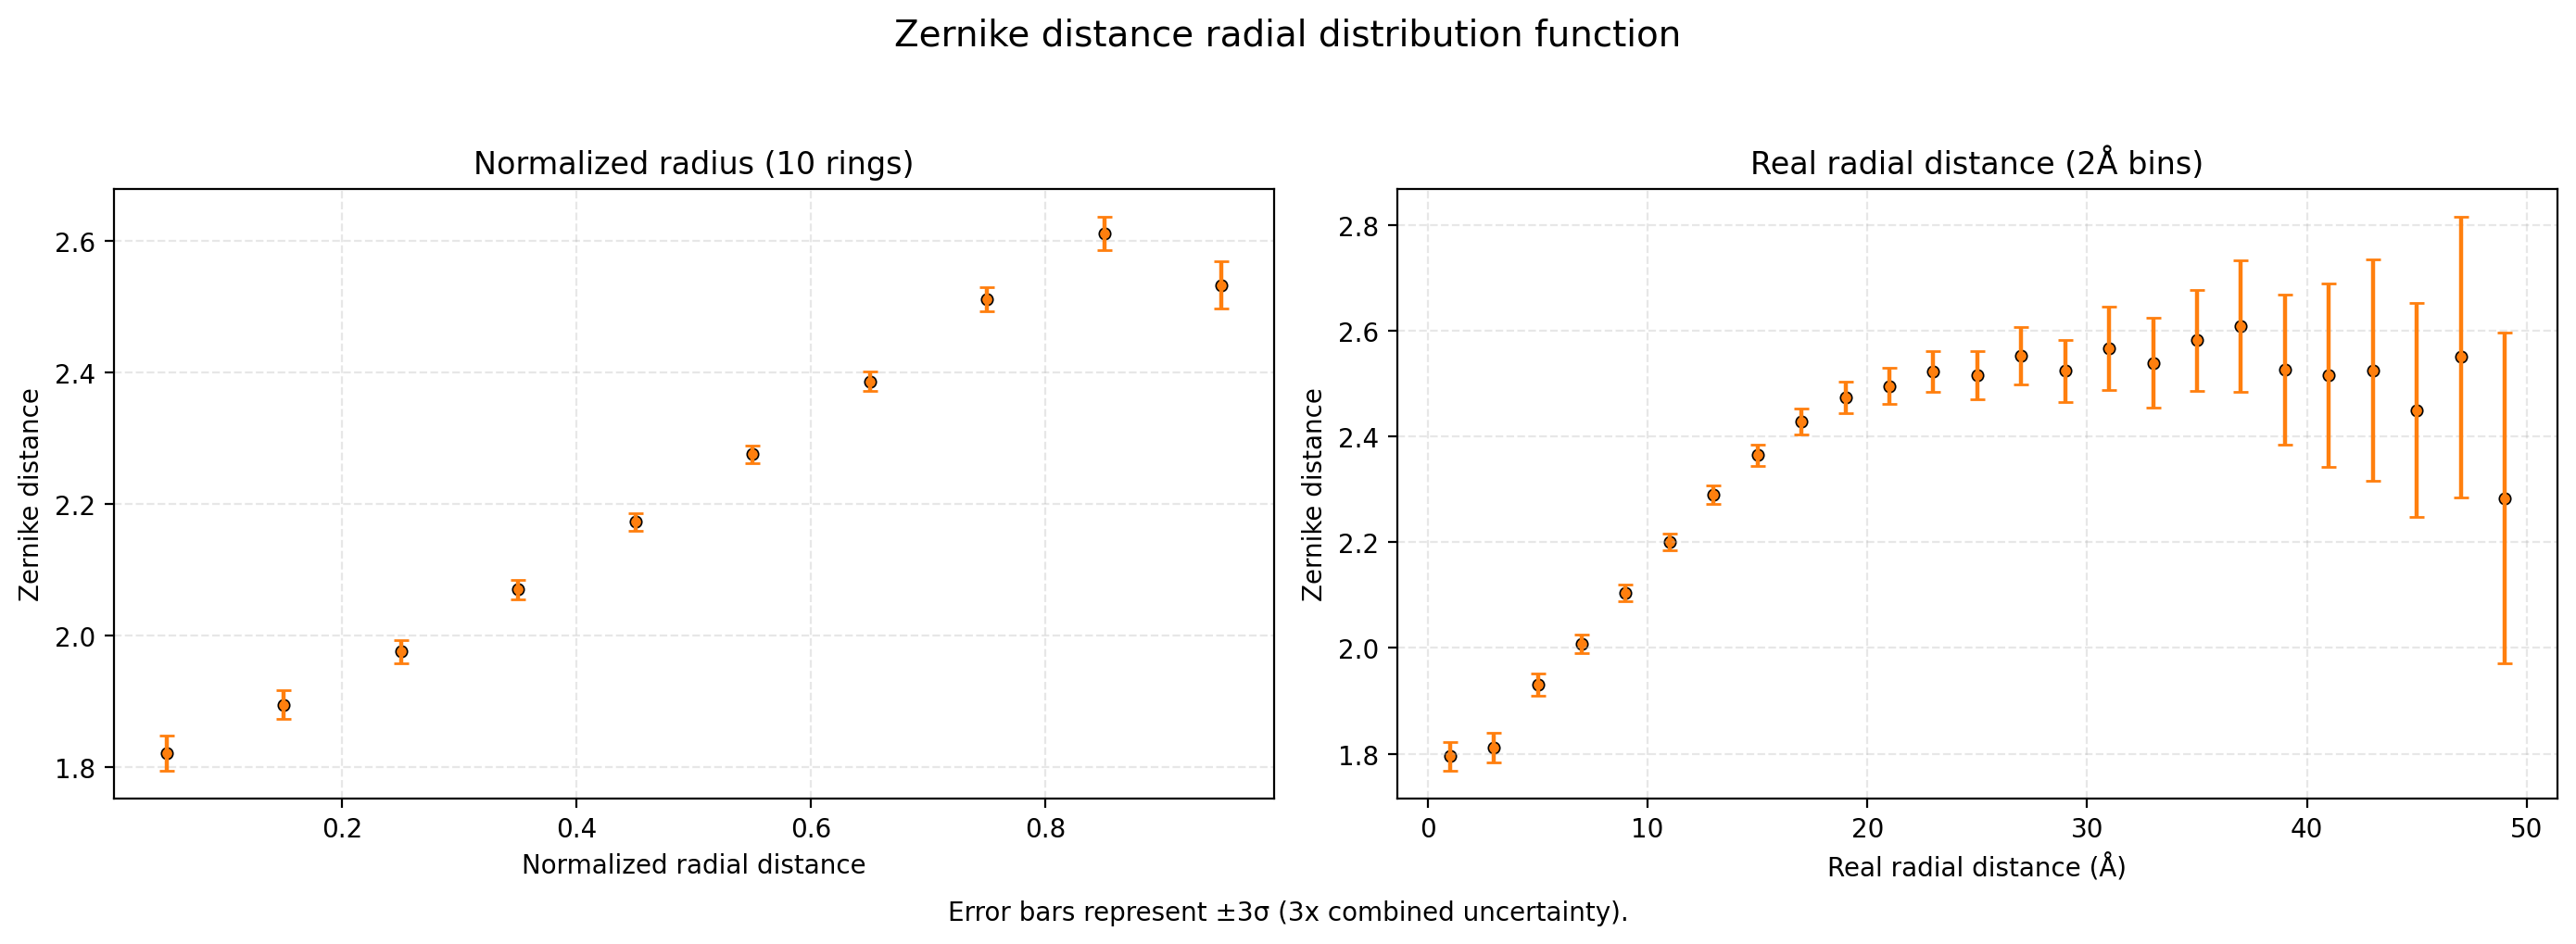

In [3]:
import re

# Usa solo i dati all_native e solo valori raw
plot_df = all_native_df.copy()

# Ring disponibili dai nomi colonna
ring_pattern = re.compile(r'^physical_ring(\d+)_mean$')
ring_ids = sorted({int(m.group(1)) for c in plot_df.columns for m in [ring_pattern.match(c)] if m})
n_rings = len(ring_ids)

# Asse x normalizzato (centro anello su [0, 1])
x_norm = np.array([(rid - 0.5) / n_rings for rid in ring_ids], dtype=float)

# Binning per real values
bin_width = 2.0
max_x = 50.0
bin_edges = np.arange(0.0, max_x + bin_width, bin_width)
bin_centers = bin_edges[:-1] + bin_width / 2.0

# Contenitori risultati
norm_stats = {}
real_stats = {}

for metric in ['physical', 'zernike']:
    # --- Normalized radius (raw) ---
    norm_mean = []
    norm_err = []

    for rid in ring_ids:
        mean_col = f'{metric}_ring{rid}_mean'
        unc_col = f'{metric}_ring{rid}_uncertainty'

        values = pd.to_numeric(plot_df[mean_col], errors='coerce').to_numpy(dtype=float)
        values = values[np.isfinite(values)]

        if len(values) == 0:
            norm_mean.append(np.nan)
            norm_err.append(np.nan)
            continue

        sample_unc = np.std(values, ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0

        if unc_col in plot_df.columns:
            uncs = pd.to_numeric(plot_df[unc_col], errors='coerce').to_numpy(dtype=float)
            uncs = uncs[np.isfinite(uncs)]
            prop_unc = np.sqrt(np.sum(uncs ** 2)) / len(uncs) if len(uncs) > 0 else np.nan
        else:
            prop_unc = np.nan

        if np.isfinite(sample_unc) and np.isfinite(prop_unc):
            comb_unc = np.sqrt(sample_unc ** 2 + prop_unc ** 2)
        elif np.isfinite(sample_unc):
            comb_unc = sample_unc
        else:
            comb_unc = prop_unc

        norm_mean.append(np.mean(values))
        norm_err.append(comb_unc)

    norm_stats[metric] = {
        'mean': np.array(norm_mean, dtype=float),
        'err': np.array(norm_err, dtype=float),
    }

    # --- Real values (raw): usa radius di ogni complesso per posizione x ---
    per_bin_vals = {i: [] for i in range(len(bin_centers))}
    per_bin_uncs = {i: [] for i in range(len(bin_centers))}

    for _, row in plot_df.iterrows():
        radius = pd.to_numeric(row.get('radius', np.nan), errors='coerce')
        if not np.isfinite(radius) or radius <= 0:
            continue

        for rid in ring_ids:
            mean_col = f'{metric}_ring{rid}_mean'
            unc_col = f'{metric}_ring{rid}_uncertainty'

            value = pd.to_numeric(row.get(mean_col, np.nan), errors='coerce')
            if not np.isfinite(value):
                continue

            x_real = (rid - 0.5) * radius / n_rings
            if not np.isfinite(x_real) or x_real < 0 or x_real > max_x:
                continue

            bin_idx = int(np.floor(x_real / bin_width))
            bin_idx = min(bin_idx, len(bin_centers) - 1)
            per_bin_vals[bin_idx].append(float(value))

            unc_val = pd.to_numeric(row.get(unc_col, np.nan), errors='coerce')
            if np.isfinite(unc_val):
                per_bin_uncs[bin_idx].append(float(unc_val))

    real_mean = []
    real_err = []

    for i in range(len(bin_centers)):
        values = np.array(per_bin_vals[i], dtype=float)
        values = values[np.isfinite(values)]

        if len(values) == 0:
            real_mean.append(np.nan)
            real_err.append(np.nan)
            continue

        sample_unc = np.std(values, ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0

        uncs = np.array(per_bin_uncs[i], dtype=float)
        uncs = uncs[np.isfinite(uncs)]
        prop_unc = np.sqrt(np.sum(uncs ** 2)) / len(uncs) if len(uncs) > 0 else np.nan

        if np.isfinite(sample_unc) and np.isfinite(prop_unc):
            comb_unc = np.sqrt(sample_unc ** 2 + prop_unc ** 2)
        elif np.isfinite(sample_unc):
            comb_unc = sample_unc
        else:
            comb_unc = prop_unc

        real_mean.append(np.mean(values))
        real_err.append(comb_unc)

    real_stats[metric] = {
        'mean': np.array(real_mean, dtype=float),
        'err': np.array(real_err, dtype=float),
    }

# ---- Figura 1x2: Physical ----
fig_phys, axes_phys = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes_phys[0].errorbar(x_norm, norm_stats['physical']['mean'], yerr=3.0 * norm_stats['physical']['err'], fmt='none', ecolor='#1f77b4', elinewidth=1.6, capsize=3)
axes_phys[0].scatter(x_norm, norm_stats['physical']['mean'], s=20, color='#1f77b4', edgecolors='black', linewidth=0.6)
axes_phys[0].set_title('Normalized radius (10 rings)')
axes_phys[0].set_xlabel('Normalized radial distance')
axes_phys[0].set_ylabel('Physical distance (Å)')
axes_phys[0].grid(True, alpha=0.3, linestyle='--')

axes_phys[1].errorbar(bin_centers, real_stats['physical']['mean'], yerr=3.0 * real_stats['physical']['err'], fmt='none', ecolor='#1f77b4', elinewidth=1.6, capsize=3)
axes_phys[1].scatter(bin_centers, real_stats['physical']['mean'], s=20, color='#1f77b4', edgecolors='black', linewidth=0.6)
axes_phys[1].set_title('Real radial distance (2Å bins)')
axes_phys[1].set_xlabel('Real radial distance (Å)')
axes_phys[1].set_ylabel('Physical distance (Å)')
axes_phys[1].grid(True, alpha=0.3, linestyle='--')

fig_phys.suptitle('Physical distance radial distribution function', fontsize=14, y=0.99)
fig_phys.text(0.5, 0.01, 'Error bars represent ±3σ (3x combined uncertainty).', ha='center', va='bottom', fontsize=10)
fig_phys.tight_layout(rect=[0, 0.03, 1, 0.95])
fig_phys.savefig('relazione/fig03_native_physical_rdf.pdf', bbox_inches='tight')

# ---- Figura 1x2: Zernike ----
fig_z, axes_z = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes_z[0].errorbar(x_norm, norm_stats['zernike']['mean'], yerr=3.0 * norm_stats['zernike']['err'], fmt='none', ecolor='#ff7f0e', elinewidth=1.6, capsize=3)
axes_z[0].scatter(x_norm, norm_stats['zernike']['mean'], s=20, color='#ff7f0e', edgecolors='black', linewidth=0.6)
axes_z[0].set_title('Normalized radius (10 rings)')
axes_z[0].set_xlabel('Normalized radial distance')
axes_z[0].set_ylabel('Zernike distance')
axes_z[0].grid(True, alpha=0.3, linestyle='--')

axes_z[1].errorbar(bin_centers, real_stats['zernike']['mean'], yerr=3.0 * real_stats['zernike']['err'], fmt='none', ecolor='#ff7f0e', elinewidth=1.6, capsize=3)
axes_z[1].scatter(bin_centers, real_stats['zernike']['mean'], s=20, color='#ff7f0e', edgecolors='black', linewidth=0.6)
axes_z[1].set_title('Real radial distance (2Å bins)')
axes_z[1].set_xlabel('Real radial distance (Å)')
axes_z[1].set_ylabel('Zernike distance')
axes_z[1].grid(True, alpha=0.3, linestyle='--')

fig_z.suptitle('Zernike distance radial distribution function', fontsize=14, y=0.99)
fig_z.text(0.5, 0.01, 'Error bars represent ±3σ (3x combined uncertainty).', ha='center', va='bottom', fontsize=10)
fig_z.tight_layout(rect=[0, 0.03, 1, 0.95])
fig_z.savefig('relazione/fig04_native_zernike_rdf.pdf', bbox_inches='tight')

plt.show()

# Global metrics
Tutti tranne prodotto scalare hanno delle code per valori grandi, quindi è interessante studiare se le rdf variano significativamente nelle code. 
Roughness e flatness come ci si può aspettare sono molto correlate, così come gyration radius e raggio del binding site. Quindi per studiare l'andamento delle rdf al variare di queste metriche è sufficiente prenderne una per coppia: prendiamo roughness (perché a differenza della flatness per la roughness si può costruire un'altra rdf che può arricchire l'analisi) e il raggio di girazione (più robusto perché non dipende dalla metodologia con cui si sceglie il binding site e in ottica di un confronto native vs decoys non cambia tra le due categorie, mentre il raggio del binding site può cambiare tra complesso native e decoy)
Il prodotto scalare ci conferma che le coppie di punti scelte per calcolare le rdf sono effettivamente orientati in direzioni opposte, seppur non proprio antiparallele (cosa normale vista l'elevanta rugosità delle superfici di van der waals)

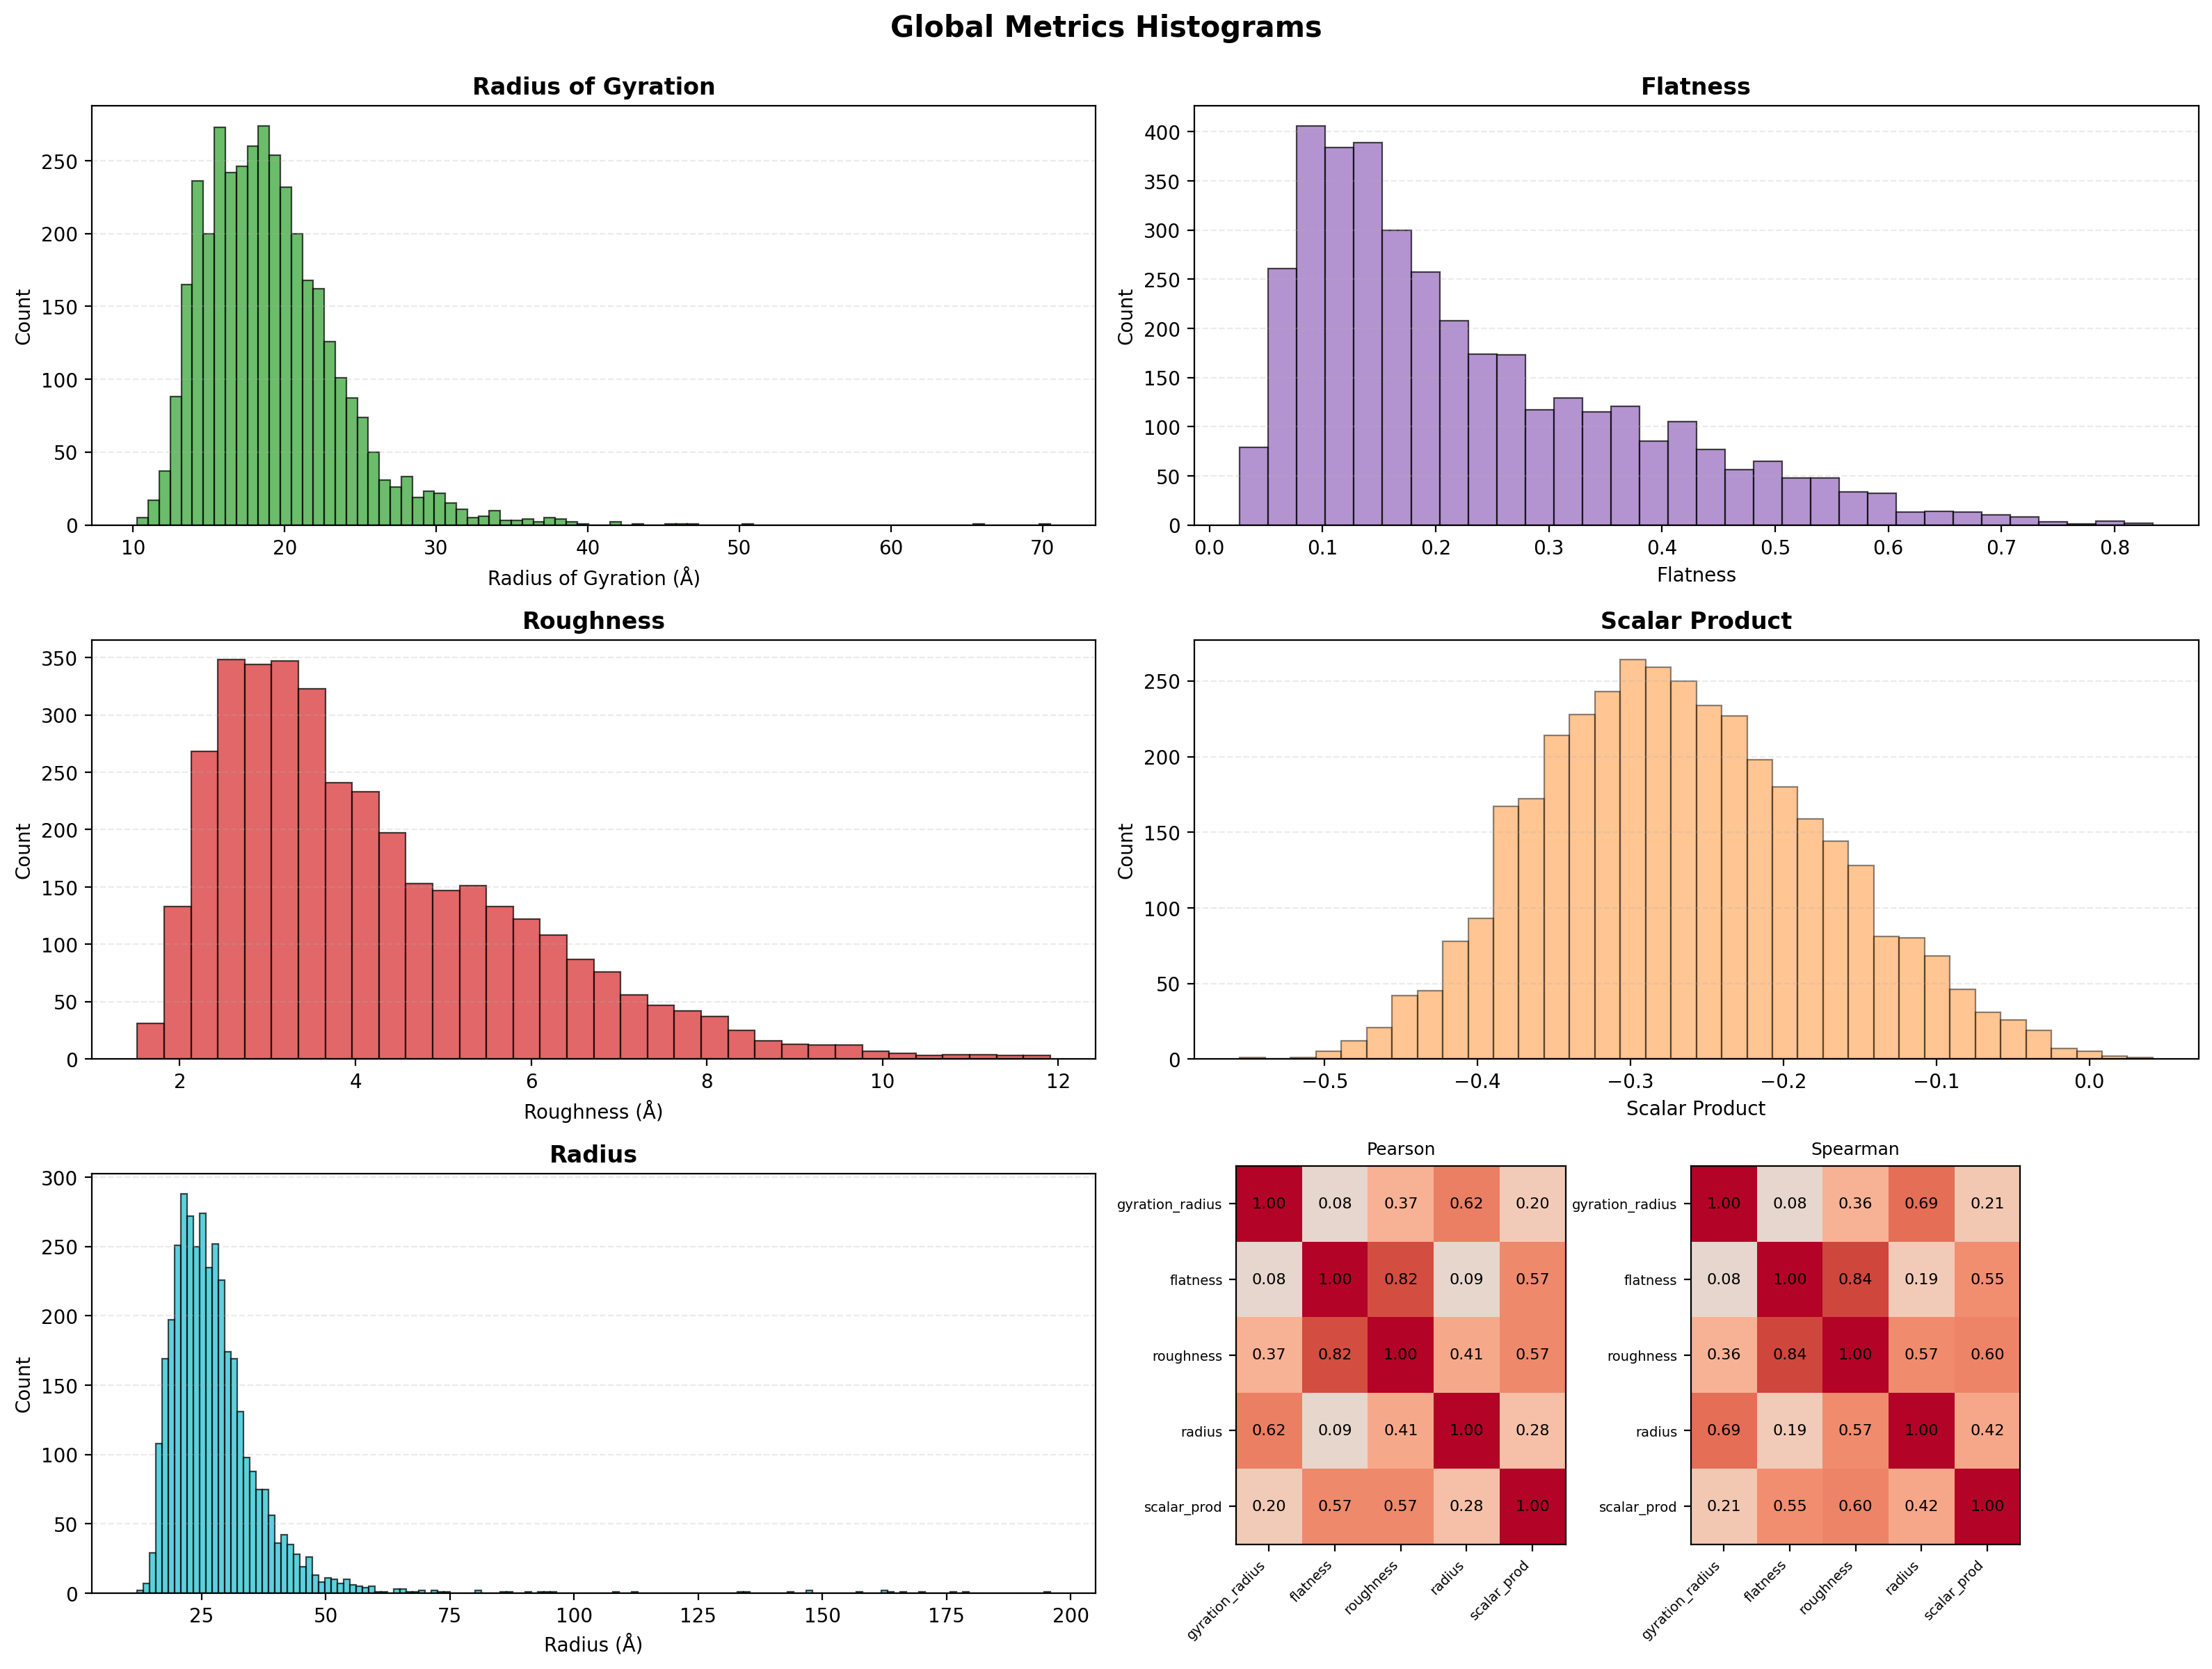

In [4]:
# Plot aggiuntivo in stile plot_histograms.py usando all_native_df
hist_df = all_native_df.copy()

if 'summary_type' not in hist_df.columns:
    raise ValueError('summary_type column not found in all_native_df')

has_both_types = (
    ('weighted' in hist_df['summary_type'].values) and
    ('normal' in hist_df['summary_type'].values)
)

def finite_series(df, column, summary_type=None):
    if column not in df.columns:
        return np.array([], dtype=float)
    subset = df
    if summary_type is not None:
        subset = subset[subset['summary_type'] == summary_type]
    vals = pd.to_numeric(subset[column], errors='coerce').to_numpy(dtype=float)
    return vals[np.isfinite(vals)]

def hist_bins(*arrays):
    valid = [a for a in arrays if len(a) > 0]
    if not valid:
        return 10
    combined = np.concatenate(valid)
    if len(combined) < 2:
        return 10
    if np.isclose(np.min(combined), np.max(combined)):
        return 10
    return np.histogram_bin_edges(combined, bins='auto')

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# 1) Gyration radius (normal)
gyr = finite_series(hist_df, 'gyration_radius', summary_type='normal')
axes[0, 0].hist(gyr, bins=hist_bins(gyr), color='#2ca02c', alpha=0.70, edgecolor='black', linewidth=0.8)
axes[0, 0].set_title('Radius of Gyration', fontweight='bold')
axes[0, 0].set_xlabel('Radius of Gyration (Å)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.25, linestyle='--')

# 2) Flatness (normal)
flat = finite_series(hist_df, 'flatness', summary_type='normal')
axes[0, 1].hist(flat, bins=hist_bins(flat), color='#9467bd', alpha=0.70, edgecolor='black', linewidth=0.8)
axes[0, 1].set_title('Flatness', fontweight='bold')
axes[0, 1].set_xlabel('Flatness')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(axis='y', alpha=0.25, linestyle='--')

# 3) Roughness (normal)
rough = finite_series(hist_df, 'roughness', summary_type='normal')
axes[1, 0].hist(rough, bins=hist_bins(rough), color='#d62728', alpha=0.70, edgecolor='black', linewidth=0.8)
axes[1, 0].set_title('Roughness', fontweight='bold')
axes[1, 0].set_xlabel('Roughness (Å)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(axis='y', alpha=0.25, linestyle='--')

# 4) Scalar product (weighted + normal overlay)
scalar_w = finite_series(hist_df, 'scalar_prod', summary_type='weighted')
scalar_n = finite_series(hist_df, 'scalar_prod', summary_type='normal')
bins_scalar = hist_bins(scalar_w, scalar_n)
axes[1, 1].hist(scalar_w, bins=bins_scalar, color='#1f77b4', alpha=0.55, edgecolor='black', linewidth=0.8, label='weighted')
axes[1, 1].hist(scalar_n, bins=bins_scalar, color='#ff7f0e', alpha=0.45, edgecolor='black', linewidth=0.8, label='normal')
axes[1, 1].set_title('Scalar Product', fontweight='bold')
axes[1, 1].set_xlabel('Scalar Product')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(axis='y', alpha=0.25, linestyle='--')
if has_both_types:
    axes[1, 1].legend(title='Summary type', fontsize=9, loc='upper left')

# 5) Radius (normal)
radius_vals = finite_series(hist_df, 'radius', summary_type='normal')
axes[2, 0].hist(radius_vals, bins=hist_bins(radius_vals), color='#17becf', alpha=0.70, edgecolor='black', linewidth=0.8)
axes[2, 0].set_title('Radius', fontweight='bold')
axes[2, 0].set_xlabel('Radius (Å)')
axes[2, 0].set_ylabel('Count')
axes[2, 0].grid(axis='y', alpha=0.25, linestyle='--')

# 6) Correlation matrices (Pearson/Spearman)
metrics = ['gyration_radius', 'flatness', 'roughness']
for c in ['gyration_radius', 'flatness', 'roughness', 'radius']:
    if c in hist_df.columns and c not in metrics:
        metrics.append(c)

corr_data = {}
for m in metrics:
    corr_data[m] = pd.to_numeric(hist_df[m], errors='coerce') if m in hist_df.columns else pd.Series([np.nan] * len(hist_df))

if 'scalar_prod' in hist_df.columns:
    if has_both_types:
        s_w = pd.Series(np.nan, index=hist_df.index, dtype='float64')
        s_n = pd.Series(np.nan, index=hist_df.index, dtype='float64')
        mask_w = hist_df['summary_type'] == 'weighted'
        mask_n = hist_df['summary_type'] == 'normal'
        s_w.loc[mask_w] = pd.to_numeric(hist_df.loc[mask_w, 'scalar_prod'], errors='coerce')
        s_n.loc[mask_n] = pd.to_numeric(hist_df.loc[mask_n, 'scalar_prod'], errors='coerce')
        corr_data['scalar_prod_weighted'] = s_w
        corr_data['scalar_prod_normal'] = s_n
    else:
        corr_data['scalar_prod'] = pd.to_numeric(hist_df['scalar_prod'], errors='coerce')

corr_df = pd.DataFrame(corr_data)
pear = corr_df.corr(method='pearson')
spea = corr_df.corr(method='spearman')

# sostituisce pannello [2,1] con due mini heatmap
a = axes[2, 1].get_position()
axes[2, 1].remove()

w = a.width * 0.42
g = a.width * 0.16
total_w = 2 * w + g
x0 = a.x0 + (a.width - total_w) / 2.0 + a.width * 0.03
y0 = a.y0 - a.height * 0.14

axp = fig.add_axes([x0, y0, w, a.height])
axs = fig.add_axes([x0 + w + g, y0, w, a.height])

axp.imshow(pear.values, cmap='coolwarm', vmin=-1.0, vmax=1.0, aspect='auto')
axp.set_xticks(range(len(pear.columns)))
axp.set_yticks(range(len(pear.index)))
axp.set_xticklabels(pear.columns, rotation=45, ha='right', fontsize=7)
axp.set_yticklabels(pear.index, fontsize=7)
axp.set_title('Pearson', fontsize=9)
for i in range(pear.shape[0]):
    for j in range(pear.shape[1]):
        v = pear.iat[i, j]
        axp.text(j, i, 'n/a' if pd.isna(v) else f'{v:.2f}', ha='center', va='center', fontsize=8)

axs.imshow(spea.values, cmap='coolwarm', vmin=-1.0, vmax=1.0, aspect='auto')
axs.set_xticks(range(len(spea.columns)))
axs.set_yticks(range(len(spea.index)))
axs.set_xticklabels(spea.columns, rotation=45, ha='right', fontsize=7)
axs.set_yticklabels(spea.index, fontsize=7)
axs.set_title('Spearman', fontsize=9)
for i in range(spea.shape[0]):
    for j in range(spea.shape[1]):
        v = spea.iat[i, j]
        axs.text(j, i, 'n/a' if pd.isna(v) else f'{v:.2f}', ha='center', va='center', fontsize=8)

fig.suptitle('Global Metrics Histograms', fontsize=15, fontweight='bold', y=0.995)
fig.tight_layout()
plt.savefig('relazione/fig05_native_global_metrics.pdf', bbox_inches='tight')
plt.show()

La metrica che più influenza l'andamento funzionale delle RDF è il raggio di girazione: in particolare più è alto (proteine meno globulari) e più la RDF Zernike si appiattisce

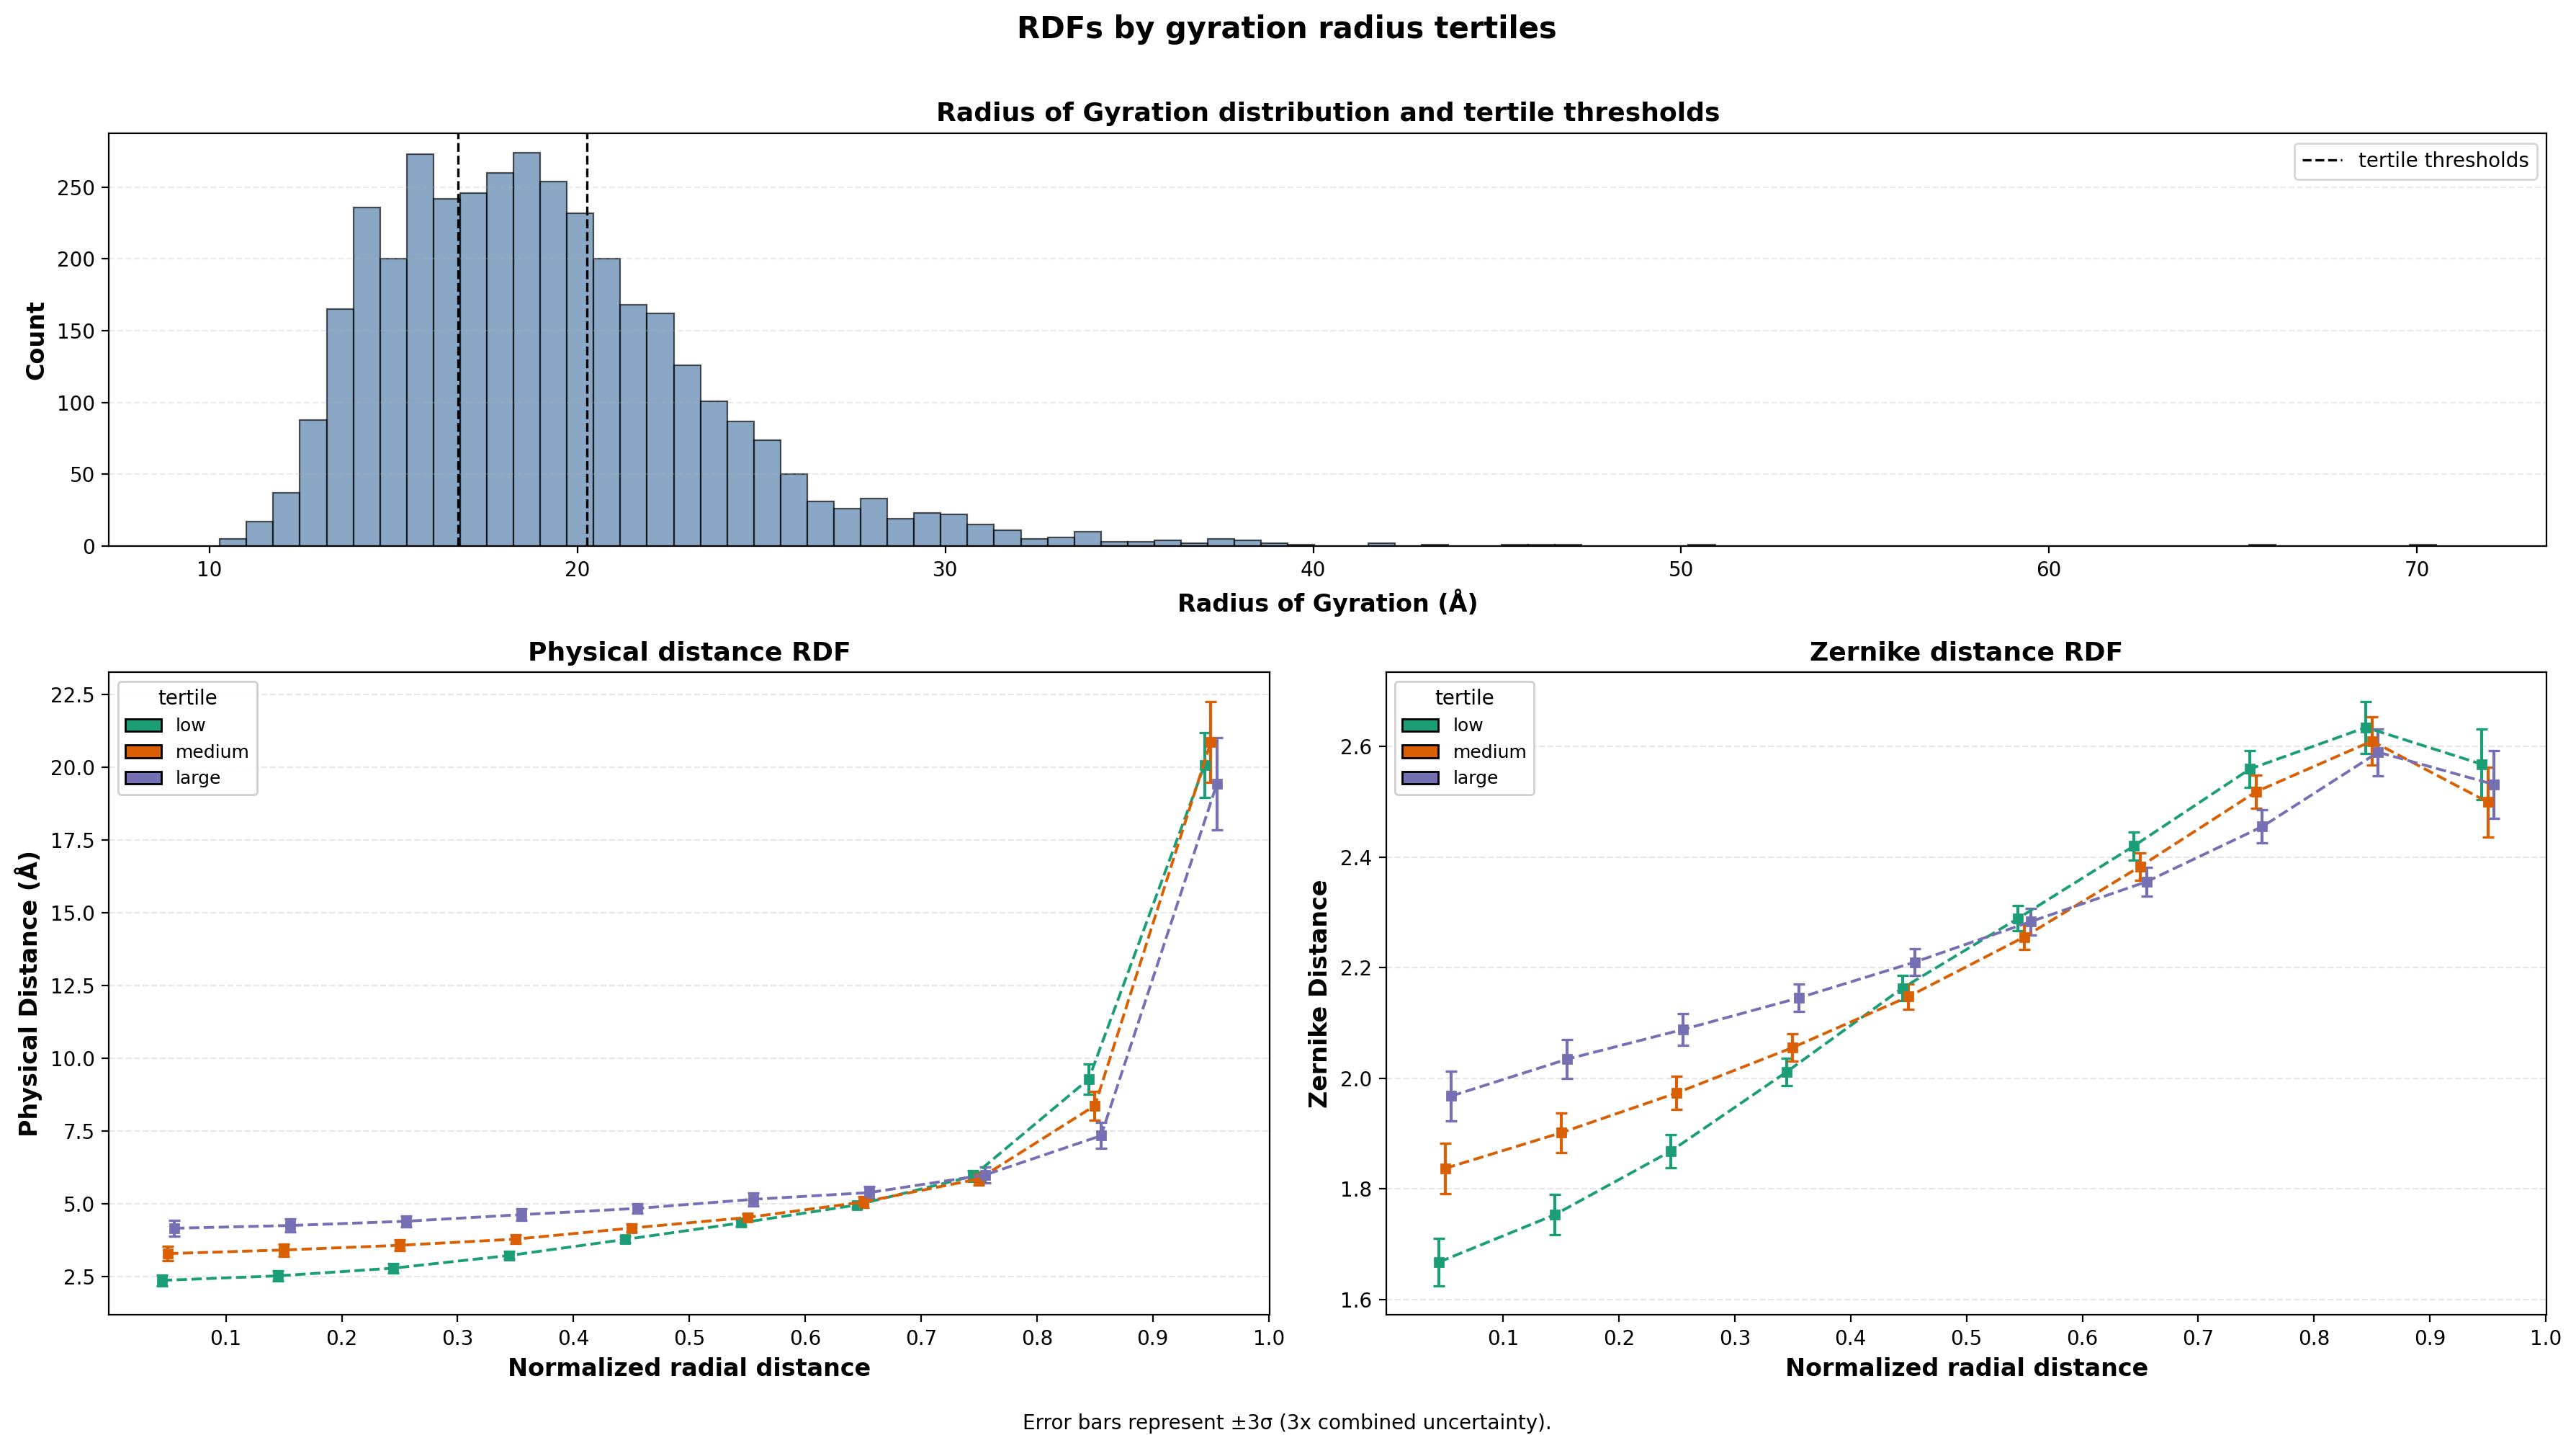

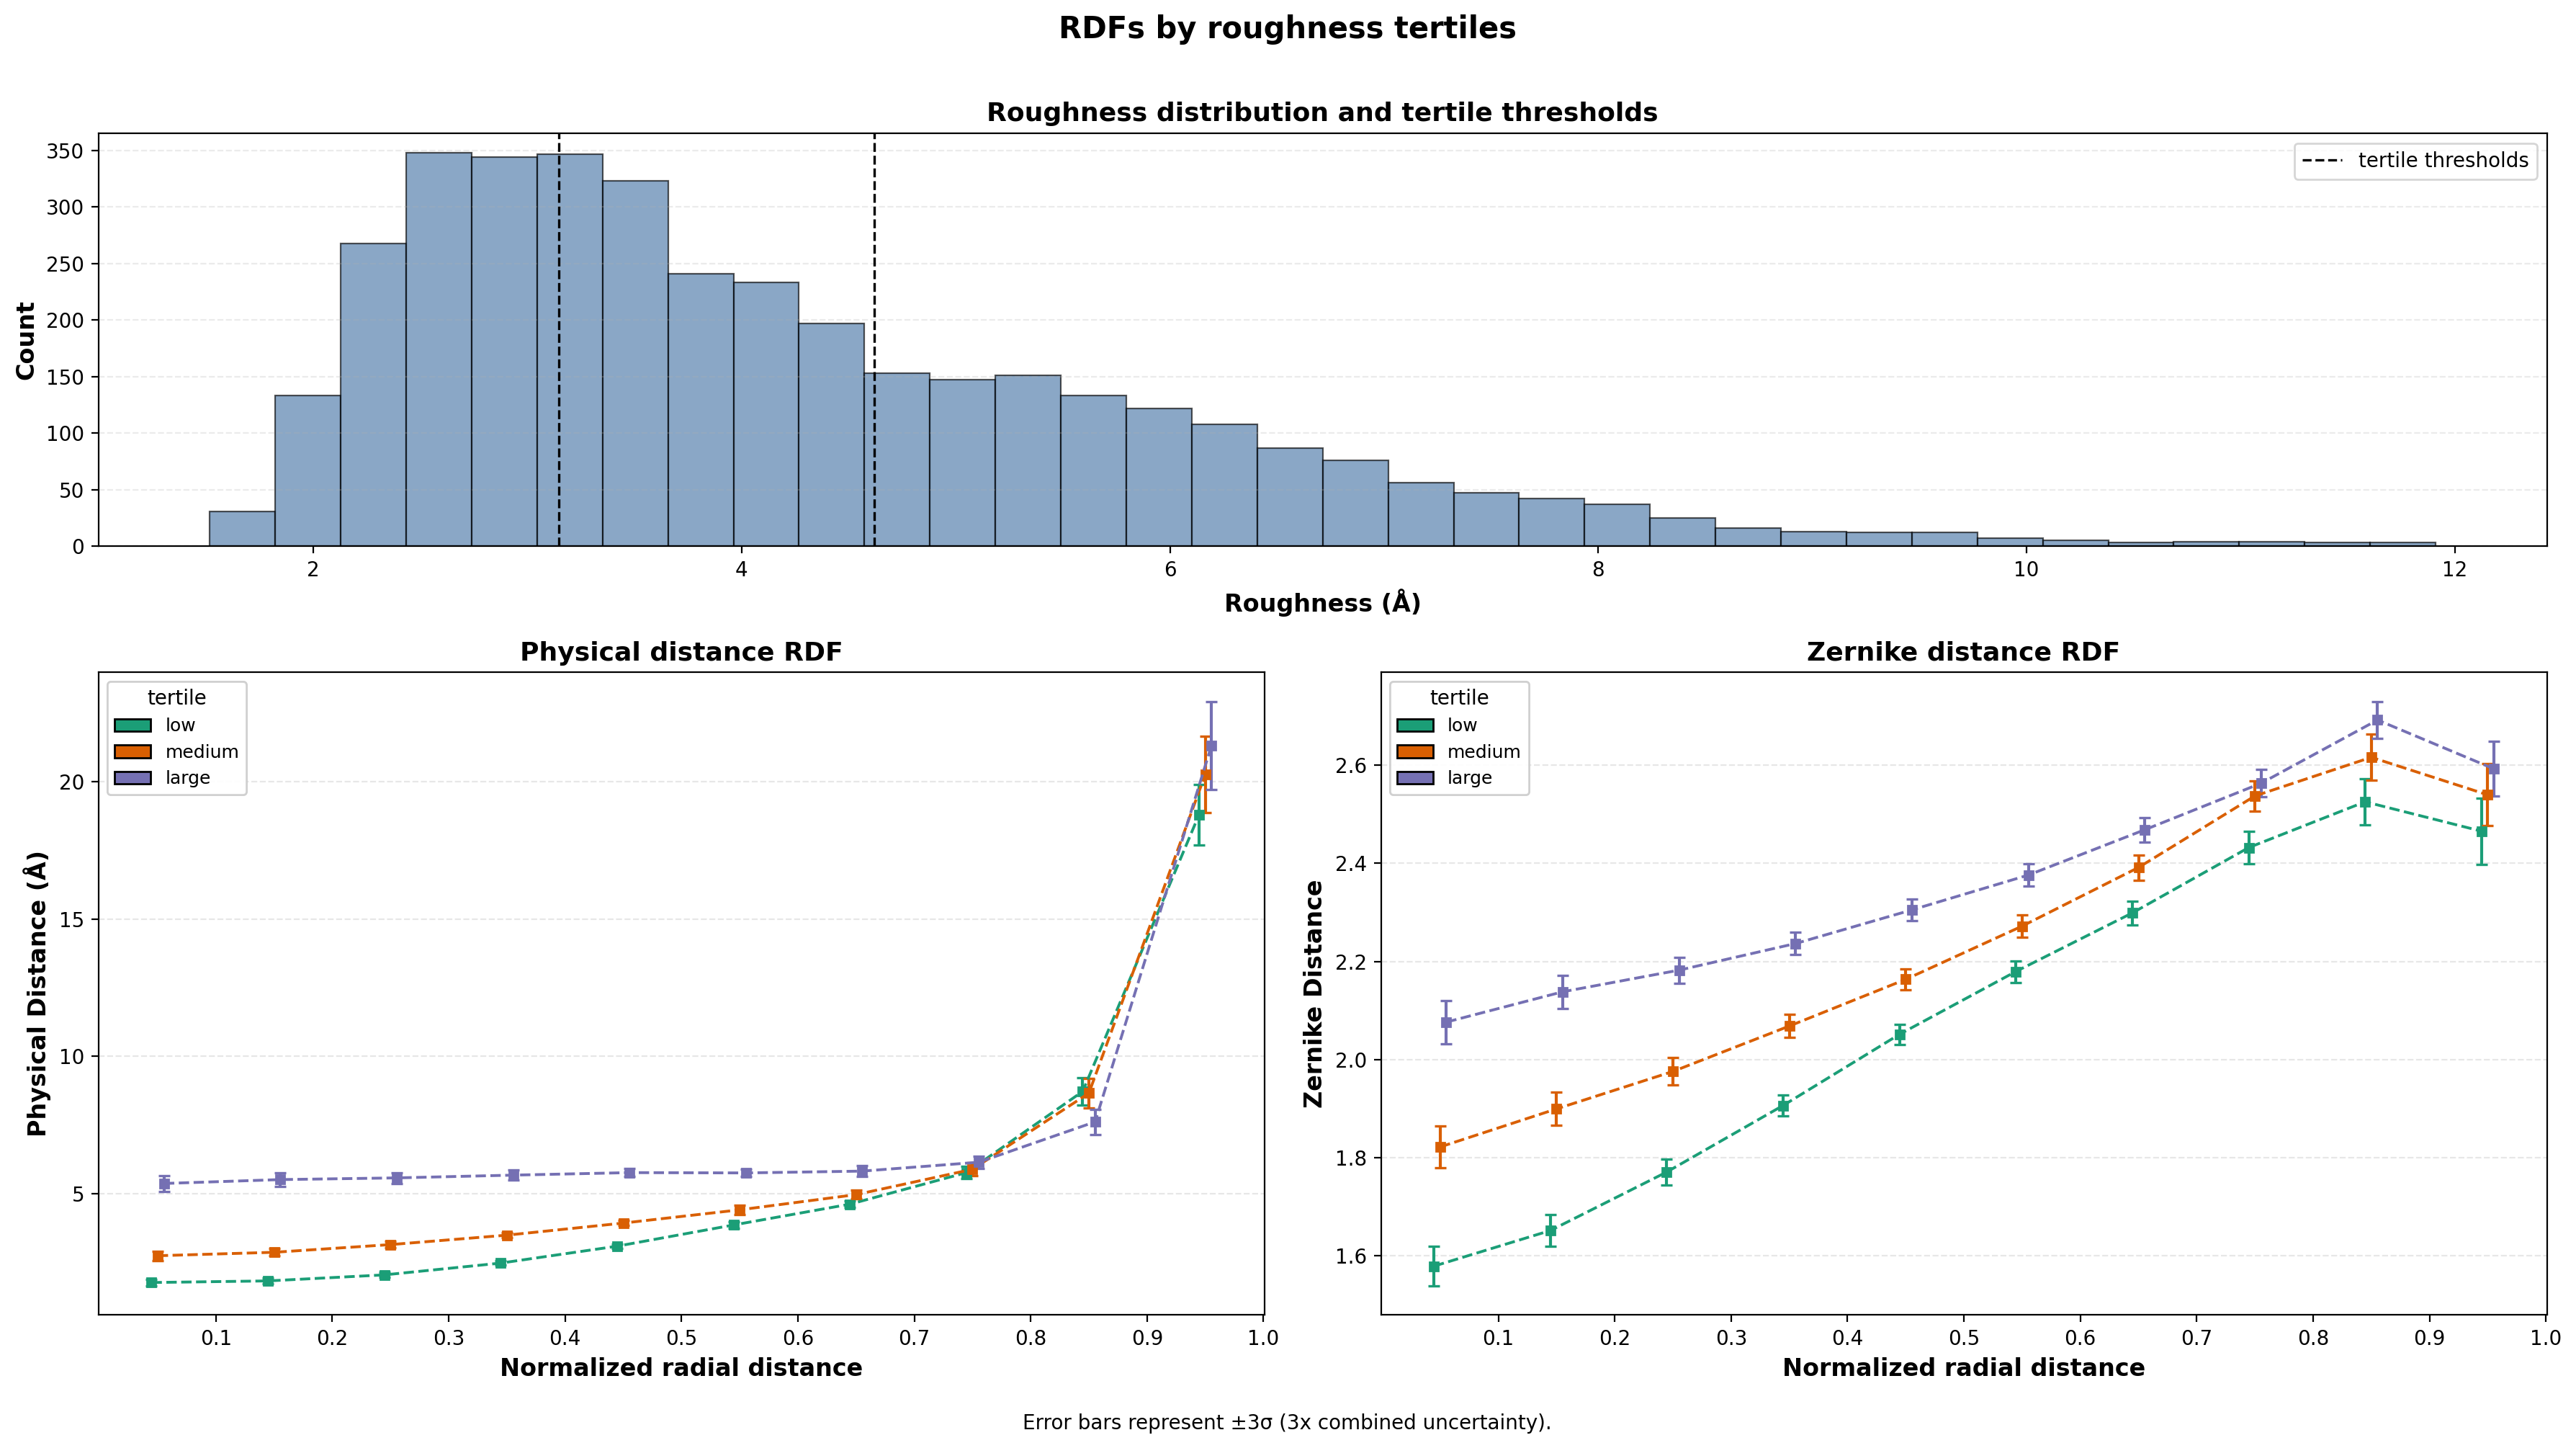

In [5]:
from matplotlib.patches import Patch

# Tertile plots (solo gyration_radius e roughness, solo raggio normalizzato)
tertile_features = ['gyration_radius', 'roughness']
tertiles = ['low', 'medium', 'large']
tertile_colors = {'low': '#1b9e77', 'medium': '#d95f02', 'large': '#7570b3'}
summary_styles = {'weighted': {'marker': 'o', 'linestyle': '-'}, 'normal': {'marker': 's', 'linestyle': '--'}}

rdf_df = all_native_df.copy()
ring_ids = sorted(
    int(col.replace('physical_ring', '').replace('_mean', ''))
    for col in rdf_df.columns
    if col.startswith('physical_ring') and col.endswith('_mean')
)
x_pos = np.arange(len(ring_ids), dtype=float)
summary_types = [st for st in ['weighted', 'normal'] if st in rdf_df['summary_type'].dropna().unique()]

for feature_name in tertile_features:
    if feature_name not in rdf_df.columns:
        print(f'Skip: {feature_name} non presente nel dataframe')
        continue

    # valore feature per complesso (primo valore finito)
    feature_rows = []
    for complex_name, grp in rdf_df.groupby('complex_name', sort=False):
        vals = pd.to_numeric(grp[feature_name], errors='coerce').to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            feature_rows.append((complex_name, float(vals[0])))

    feature_df = pd.DataFrame(feature_rows, columns=['complex_name', feature_name])
    feature_values = feature_df[feature_name].to_numpy(dtype=float)

    if len(feature_values) == 0:
        print(f'Skip: nessun valore valido per {feature_name}')
        continue

    q1, q2 = np.quantile(feature_values, [1 / 3, 2 / 3])

    tertile_complexes = {t: [] for t in tertiles}
    for _, row in feature_df.iterrows():
        val = row[feature_name]
        if val <= q1:
            tertile_complexes['low'].append(row['complex_name'])
        elif val <= q2:
            tertile_complexes['medium'].append(row['complex_name'])
        else:
            tertile_complexes['large'].append(row['complex_name'])

    # Aggregazione ring-by-ring per tertile, summary_type e metrica
    agg = {t: {'physical': {}, 'zernike': {}} for t in tertiles}

    for tertile in tertiles:
        selected = set(tertile_complexes[tertile])

        for metric in ['physical', 'zernike']:
            for summary_type in summary_types:
                grp = rdf_df[(rdf_df['summary_type'] == summary_type) & (rdf_df['complex_name'].isin(selected))]

                ring_mean = []
                ring_unc = []

                for rid in ring_ids:
                    mean_col = f'{metric}_ring{rid}_mean'
                    unc_col = f'{metric}_ring{rid}_uncertainty'

                    vals = pd.to_numeric(grp[mean_col], errors='coerce').to_numpy(dtype=float)
                    vals = vals[np.isfinite(vals)]

                    if len(vals) == 0:
                        ring_mean.append(np.nan)
                        ring_unc.append(np.nan)
                        continue

                    mean_val = float(np.mean(vals))
                    sample_unc = float(np.std(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else 0.0

                    if unc_col in grp.columns:
                        uncs = pd.to_numeric(grp[unc_col], errors='coerce').to_numpy(dtype=float)
                        uncs = uncs[np.isfinite(uncs)]
                        prop_unc = float(np.sqrt(np.sum(uncs ** 2)) / len(uncs)) if len(uncs) > 0 else np.nan
                    else:
                        prop_unc = np.nan

                    if np.isfinite(sample_unc) and np.isfinite(prop_unc):
                        comb_unc = float(np.sqrt(sample_unc ** 2 + prop_unc ** 2))
                    elif np.isfinite(sample_unc):
                        comb_unc = float(sample_unc)
                    else:
                        comb_unc = float(prop_unc)

                    ring_mean.append(mean_val)
                    ring_unc.append(comb_unc)

                agg[tertile][metric][summary_type] = {
                    'mean': np.array(ring_mean, dtype=float),
                    'unc': np.array(ring_unc, dtype=float),
                }

    # ---- Plot per singola feature ----
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[0.9, 1.4])
    ax_hist = fig.add_subplot(gs[0, :])
    ax_phys = fig.add_subplot(gs[1, 0])
    ax_zern = fig.add_subplot(gs[1, 1])

    # histogramma feature + soglie tertili
    hist_bins = np.histogram_bin_edges(feature_values, bins='auto') if len(feature_values) > 1 else 10
    ax_hist.hist(feature_values, bins=hist_bins, color='#4c78a8', alpha=0.65, edgecolor='black', linewidth=0.8)
    ax_hist.axvline(q1, color='black', linestyle='--', linewidth=1.2, label='tertile thresholds')
    ax_hist.axvline(q2, color='black', linestyle='--', linewidth=1.2)
    xlab = f'Radius of Gyration (Å)' if feature_name == 'gyration_radius' else f'Roughness (Å)'
    ax_hist.set_title(f'Radius of Gyration distribution and tertile thresholds' if feature_name == 'gyration_radius' else f'Roughness distribution and tertile thresholds', fontsize=13, fontweight='bold')
    ax_hist.set_xlabel(xlab, fontsize=12, fontweight='bold')
    ax_hist.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax_hist.grid(axis='y', alpha=0.25, linestyle='--')
    ax_hist.legend(fontsize=10)

    # physical + zernike panels
    for ax, metric, ylabel in [
        (ax_phys, 'physical', 'Physical Distance (Å)'),
        (ax_zern, 'zernike', 'Zernike Distance'),
    ]:
        series_count = max(len(tertiles) * len(summary_types), 1)
        offset_step = 0.16 / series_count
        s_idx = 0

        for tertile in tertiles:
            for summary_type in summary_types:
                data = agg[tertile][metric][summary_type]
                means = data['mean']
                unc = data['unc']
                x_offset = (s_idx - (series_count - 1) / 2) * offset_step
                style = summary_styles.get(summary_type, {'marker': 'o', 'linestyle': '-'})

                ax.errorbar(
                    (x_pos + x_offset)/10.0 - 0.05,
                    means,
                    yerr=3.0 * unc,
                    fmt='none',
                    ecolor=tertile_colors[tertile],
                    elinewidth=1.5,
                    capsize=3,
                    capthick=1.2,
                    zorder=2,
                )
                ax.plot(
                    (x_pos + x_offset)/10.0 - 0.05,
                    means,
                    color=tertile_colors[tertile],
                    marker=style['marker'],
                    linestyle=style['linestyle'],
                    linewidth=1.4,
                    markersize=4.5,
                    label=f'{tertile} / {summary_type}',
                    zorder=3,
                )
                s_idx += 1

        ax.set_xlabel('Normalized radial distance', fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos/10.0)
        ax.set_xticklabels([str(r/10.0) for r in ring_ids])
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        tertile_handles = [
            Patch(facecolor=tertile_colors[t], edgecolor='black', label=t)
            for t in tertiles
        ]
        legend1 = ax.legend(handles=tertile_handles, title='tertile', fontsize=9, loc='upper left')
        ax.add_artist(legend1)

    ax_phys.set_title('Physical distance RDF', fontsize=13, fontweight='bold')
    ax_zern.set_title('Zernike distance RDF', fontsize=13, fontweight='bold')

    fig.suptitle('RDFs by gyration radius tertiles' if feature_name == 'gyration_radius' else 'RDFs by roughness tertiles', fontsize=15, fontweight='bold', y=0.995)
    fig.text(0.5, 0.01, 'Error bars represent ±3σ (3x combined uncertainty).', ha='center', va='bottom', fontsize=10)
    fig.tight_layout(rect=(0, 0.03, 1, 0.985))

    if feature_name == 'gyration_radius':
        fig.savefig('relazione/fig06_native_rdf_by_gyration_radius.pdf', bbox_inches='tight')
    elif feature_name == 'roughness':
        fig.savefig('relazione/fig07_native_rdf_by_roughness.pdf', bbox_inches='tight')

    plt.show()

# Problema
Se si guarda la RDF della distanza fisica negli ultimi anelli essa supera i 5Å, anche abbondantemente nell'ultimo anello. Questo è strano, perché i binding site su cui si fa l'analisi sono selezionati affinché ogni punto di una proteina abbia almeno un punto nell'altra a meno di 5Å: vuol dire che il metodo di sampling non sta funzionando bene.

Questo potrebbe essere potenzialmente un problema perché vuol dire che sto considerando anche coppie che in realtà sicuramente non interagiscono e può falsare l'analisi. In particolare nelle RDF con la distanza radiale in angstrom nella zona centrale si mischiano gli anelli centrali dei complessi con raggio del binding site grande e gli ultimi anelli (quelli problematici perché con più coppie non interagenti) dei complessi con raggio del binding site piccolo.

In effetti in questa zona per la RDF physical ho valori a metà tra l'ultimo anello (circa 20Å) e quelli precedenti (più vicini a 5Å), mentre il fatto che dopo 40Å scende di nuovo fa pensare che gli ultimi anelli dei complessi con binding site grande siano meno problematici dal punto di vista del sampling.

Nella RDF Zernike in questa zona vedo una saturazione, che comincia proprio quando la RDF physical supera i 5Å. Viene da chiedersi se anche questa sia dovuta a questo errore nel sampling.

Inoltre potrebbe influenzare anche altre analisi, precedenti e successive (magari anche il confronto native vs decoys).

Tuttavia se si guarda il violinplot sottostante la situazione è un po' meno critica di quello che appare: anche negli ultimi anelli la maggior parte dei complessi ha valori più vicini a 5Å (la linea tratteggiata). Però probabilmente il fatto di avere code molto estese porta ad avere abbastanza outlier da influenzare considerevolmente la media. 

Allora la domanda è se sia necessario effettivamente modificare il sampling e rifare le analisi oppure se basta abbandonare la rappresentazione delle RDF tramite media, usando invece dei boxplot o dei violinplot. Visto anche che le distribuzioni di alcuni anelli e bin sono fortemente asimmetriche forse abbandonare la media in favore di questi plot è meglio a prescindere se venga rifatta l'analisi oppure no.

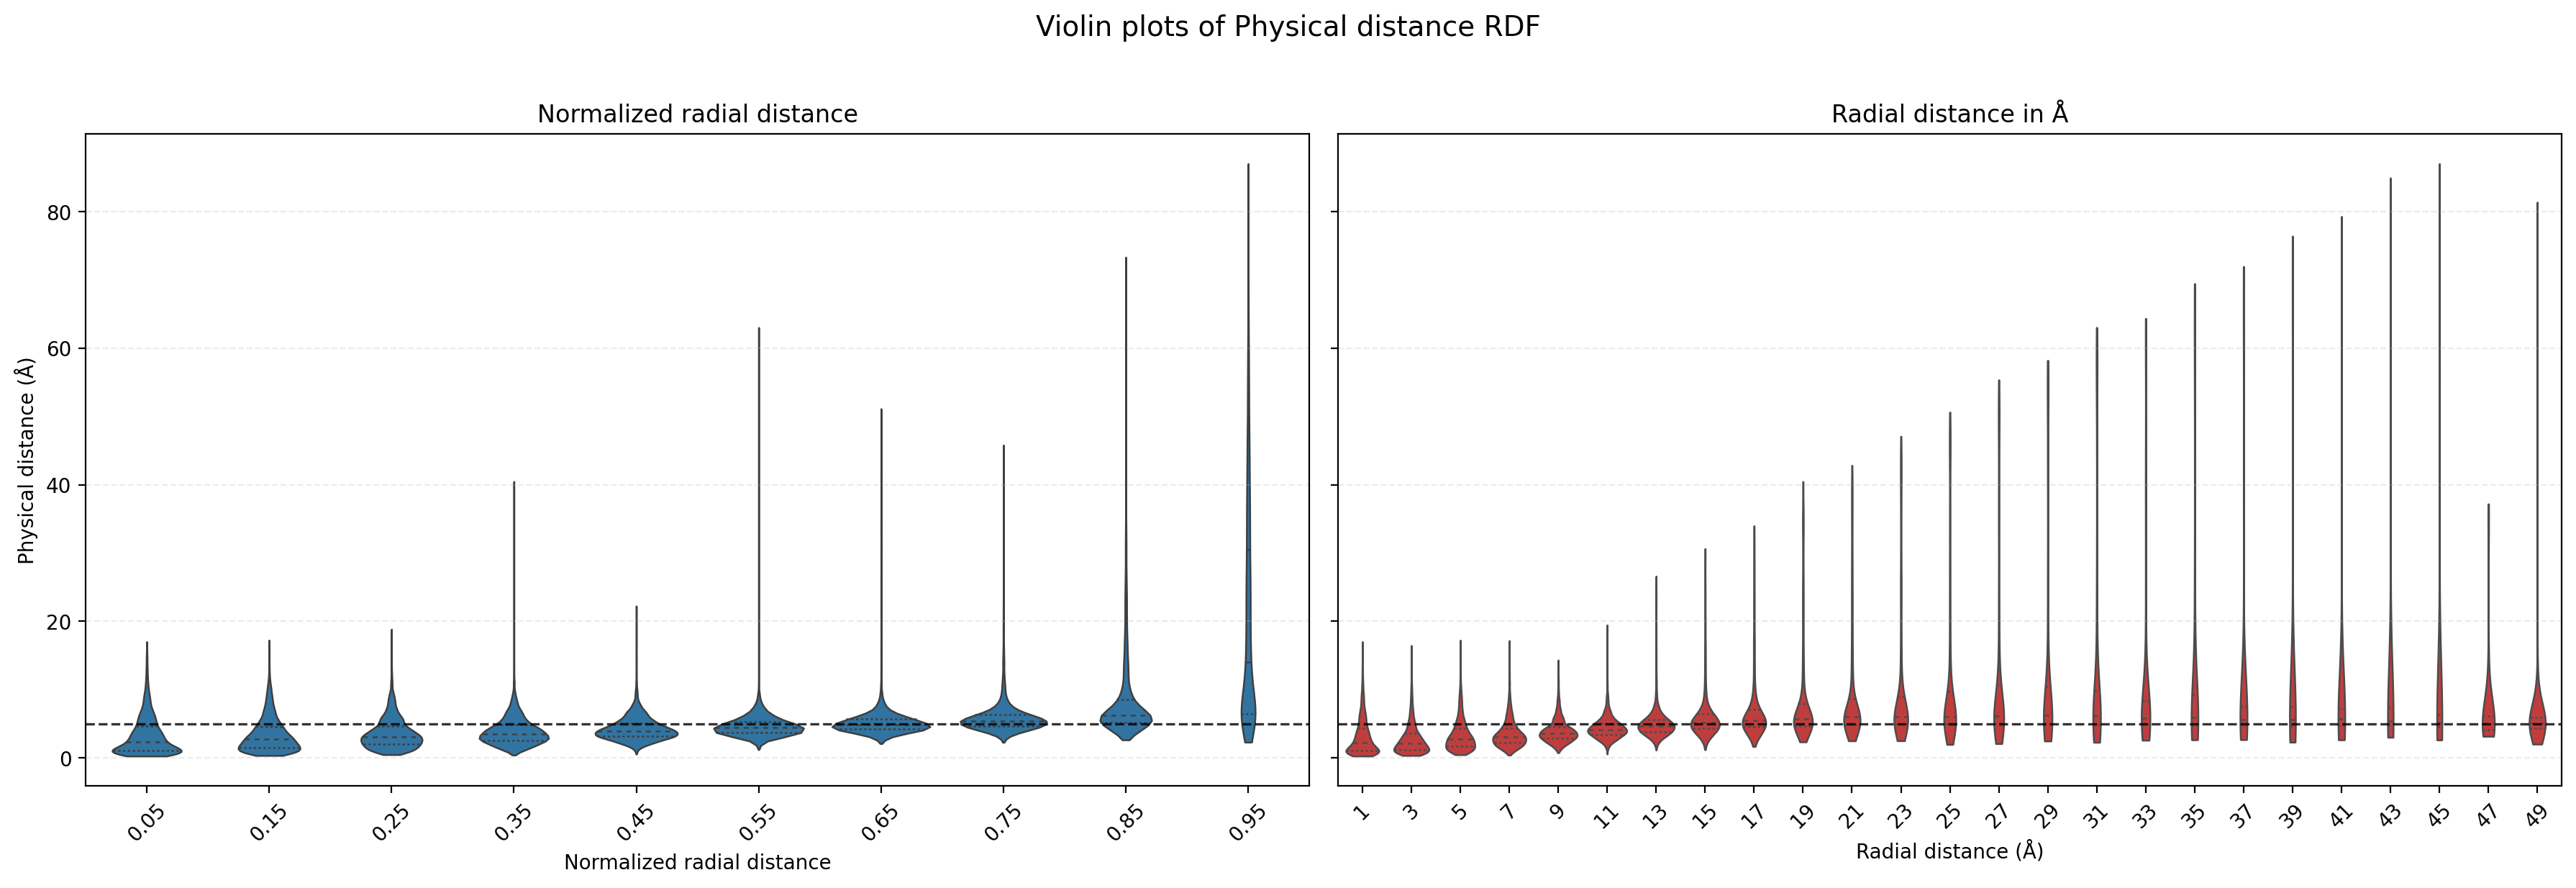

In [6]:
# Violin plot della RDF physical su all_native_df
# - pannello sinistro: distanza radiale normalizzata
# - pannello destro: distanza radiale in angstrom

rdf_df = all_native_df.copy()

if 'summary_type' in rdf_df.columns and 'normal' in rdf_df['summary_type'].dropna().unique():
    rdf_df = rdf_df[rdf_df['summary_type'] == 'normal'].copy()

ring_ids = sorted(
    int(col.replace('physical_ring', '').replace('_mean', ''))
    for col in rdf_df.columns
    if col.startswith('physical_ring') and col.endswith('_mean')
)

normalized_records = []
angstrom_records = []
bin_width = 2.0
max_radius = 50.0
n_bins = int(max_radius / bin_width)

for _, row in rdf_df.iterrows():
    radius = pd.to_numeric(row.get('radius', np.nan), errors='coerce')
    if not np.isfinite(radius) or radius <= 0:
        continue

    for ring_id in ring_ids:
        value = pd.to_numeric(row.get(f'physical_ring{ring_id}_mean', np.nan), errors='coerce')
        if not np.isfinite(value):
            continue

        normalized_records.append({
            'ring': f'{(ring_id - 0.5) / len(ring_ids):.2f}',
            'physical_distance_A': float(value),
        })

        angstrom_radius = float(radius) * (ring_id - 0.5) / len(ring_ids)
        bin_id = min(int(angstrom_radius // bin_width) + 1, n_bins)
        angstrom_bin_center = bin_id * bin_width - bin_width / 2.0
        angstrom_records.append({
            'radius_A': angstrom_radius,
            'radius_bin': f'{angstrom_bin_center:.0f}',
            'physical_distance_A': float(value),
        })

normalized_long_df = pd.DataFrame.from_records(normalized_records)
angstrom_long_df = pd.DataFrame.from_records(angstrom_records)

normalized_order = [f'{(ring_id - 0.5) / len(ring_ids):.2f}' for ring_id in ring_ids]
angstrom_order = sorted(
    angstrom_long_df['radius_bin'].unique(),
    key=lambda value: float(value),
) if not angstrom_long_df.empty else []

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.violinplot(
    data=normalized_long_df,
    x='ring',
    y='physical_distance_A',
    order=normalized_order,
    ax=axes[0],
    color='#1f77b4',
    inner='quartile',
    cut=0,
    linewidth=0.9,
)
axes[0].axhline(5, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[0].set_title('Normalized radial distance')
axes[0].set_xlabel('Normalized radial distance')
axes[0].set_ylabel('Physical distance (Å)')
axes[0].grid(axis='y', alpha=0.25, linestyle='--')
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(
    data=angstrom_long_df,
    x='radius_bin',
    y='physical_distance_A',
    order=angstrom_order,
    ax=axes[1],
    color='#d62728',
    inner='quartile',
    cut=0,
    linewidth=0.9,
)
axes[1].axhline(5, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[1].set_title('Radial distance in Å')
axes[1].set_xlabel('Radial distance (Å)')
axes[1].set_ylabel('')
axes[1].grid(axis='y', alpha=0.25, linestyle='--')
axes[1].tick_params(axis='x', rotation=45)

fig.suptitle('Violin plots of Physical distance RDF', fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig('relazione/fig08_native_physical_distance_distributions.pdf', bbox_inches='tight')
plt.show()

Si vede anche che effettivamente le distribuzioni dopo i 20Å assomigliano molto a quelle dell'ultimo anello.

Inoltre è interessante che alcune distribuzioni sembrano troncate a valori bassi, come se ci fossero dei valori minimi che però sono molto probabili. Questo fenomeno si ripete anche per altre RDF come su vede sotto: se confermato in ottica Zernike e complementarità di forma è interessante perché vuol dire che molti complessi ottimizzano sullo stesso valore in quell'anello/bin.

Intanto riporto anche dei boxplot e dei violinplot anche per le altre RDF. Lo faccio direttamente per il confronto native vs decoys così sotto ogni grafico posso aggiungere qualche commento se noto qualcosa.

## Physical distance

### Raggio normalizzato

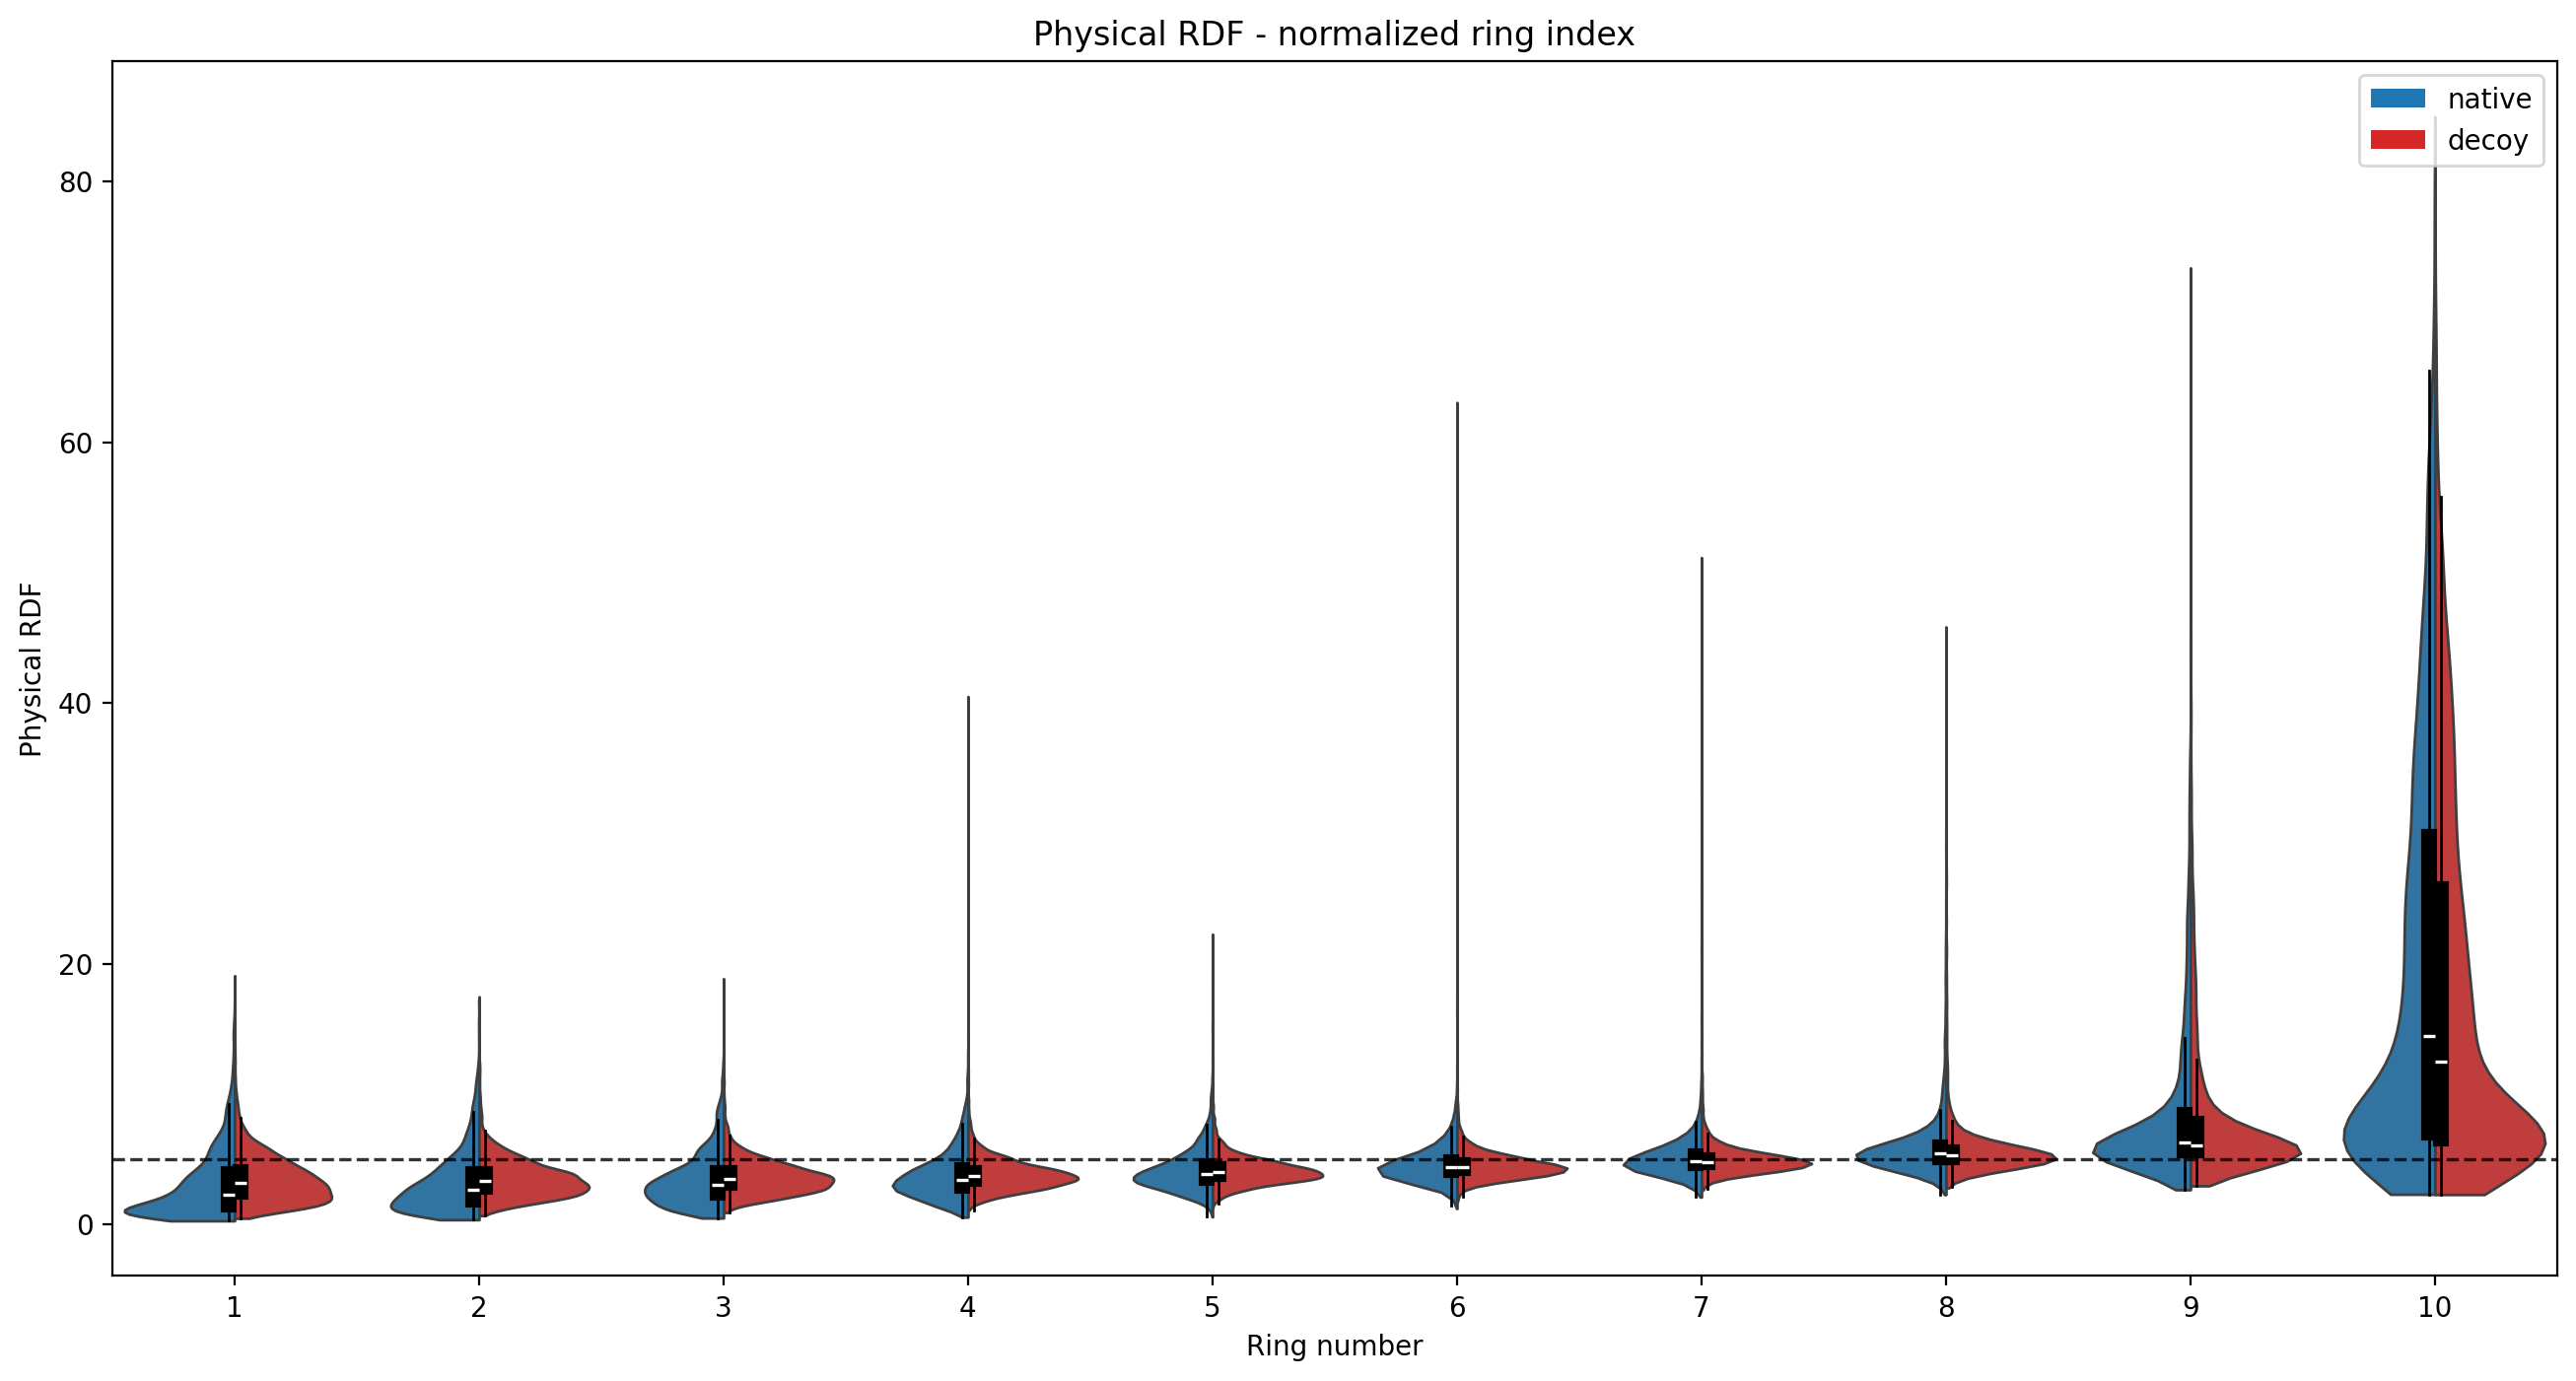

In [7]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(
    data=physical_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    split=True,
    inner=None,
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
sns.boxplot(
    data=physical_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    width=0.10,
    whis=1.5,
    showfliers=False,
    showcaps=False,
    boxprops={'facecolor': 'black', 'edgecolor': 'black', 'zorder': 3},
    whiskerprops={'color': 'black', 'linewidth': 1.0},
    capprops={'color': 'black', 'linewidth': 0.0},
    medianprops={'color': 'white', 'linewidth': 1.2, 'zorder': 5},
    ax=ax,
)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.legend(handles=[
    mpatches.Patch(facecolor=palette['native'], label='native'),
    mpatches.Patch(facecolor=palette['decoy'], label='decoy'),
], title='')
ax.axhline(5, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_title('Physical RDF - normalized ring index')
ax.set_xlabel('Ring number')
ax.set_ylabel('Physical RDF')
plt.show()

Nei primi anelli le distribuzioni dei decoys sembrano più simmetriche

### Raggio in angstrom

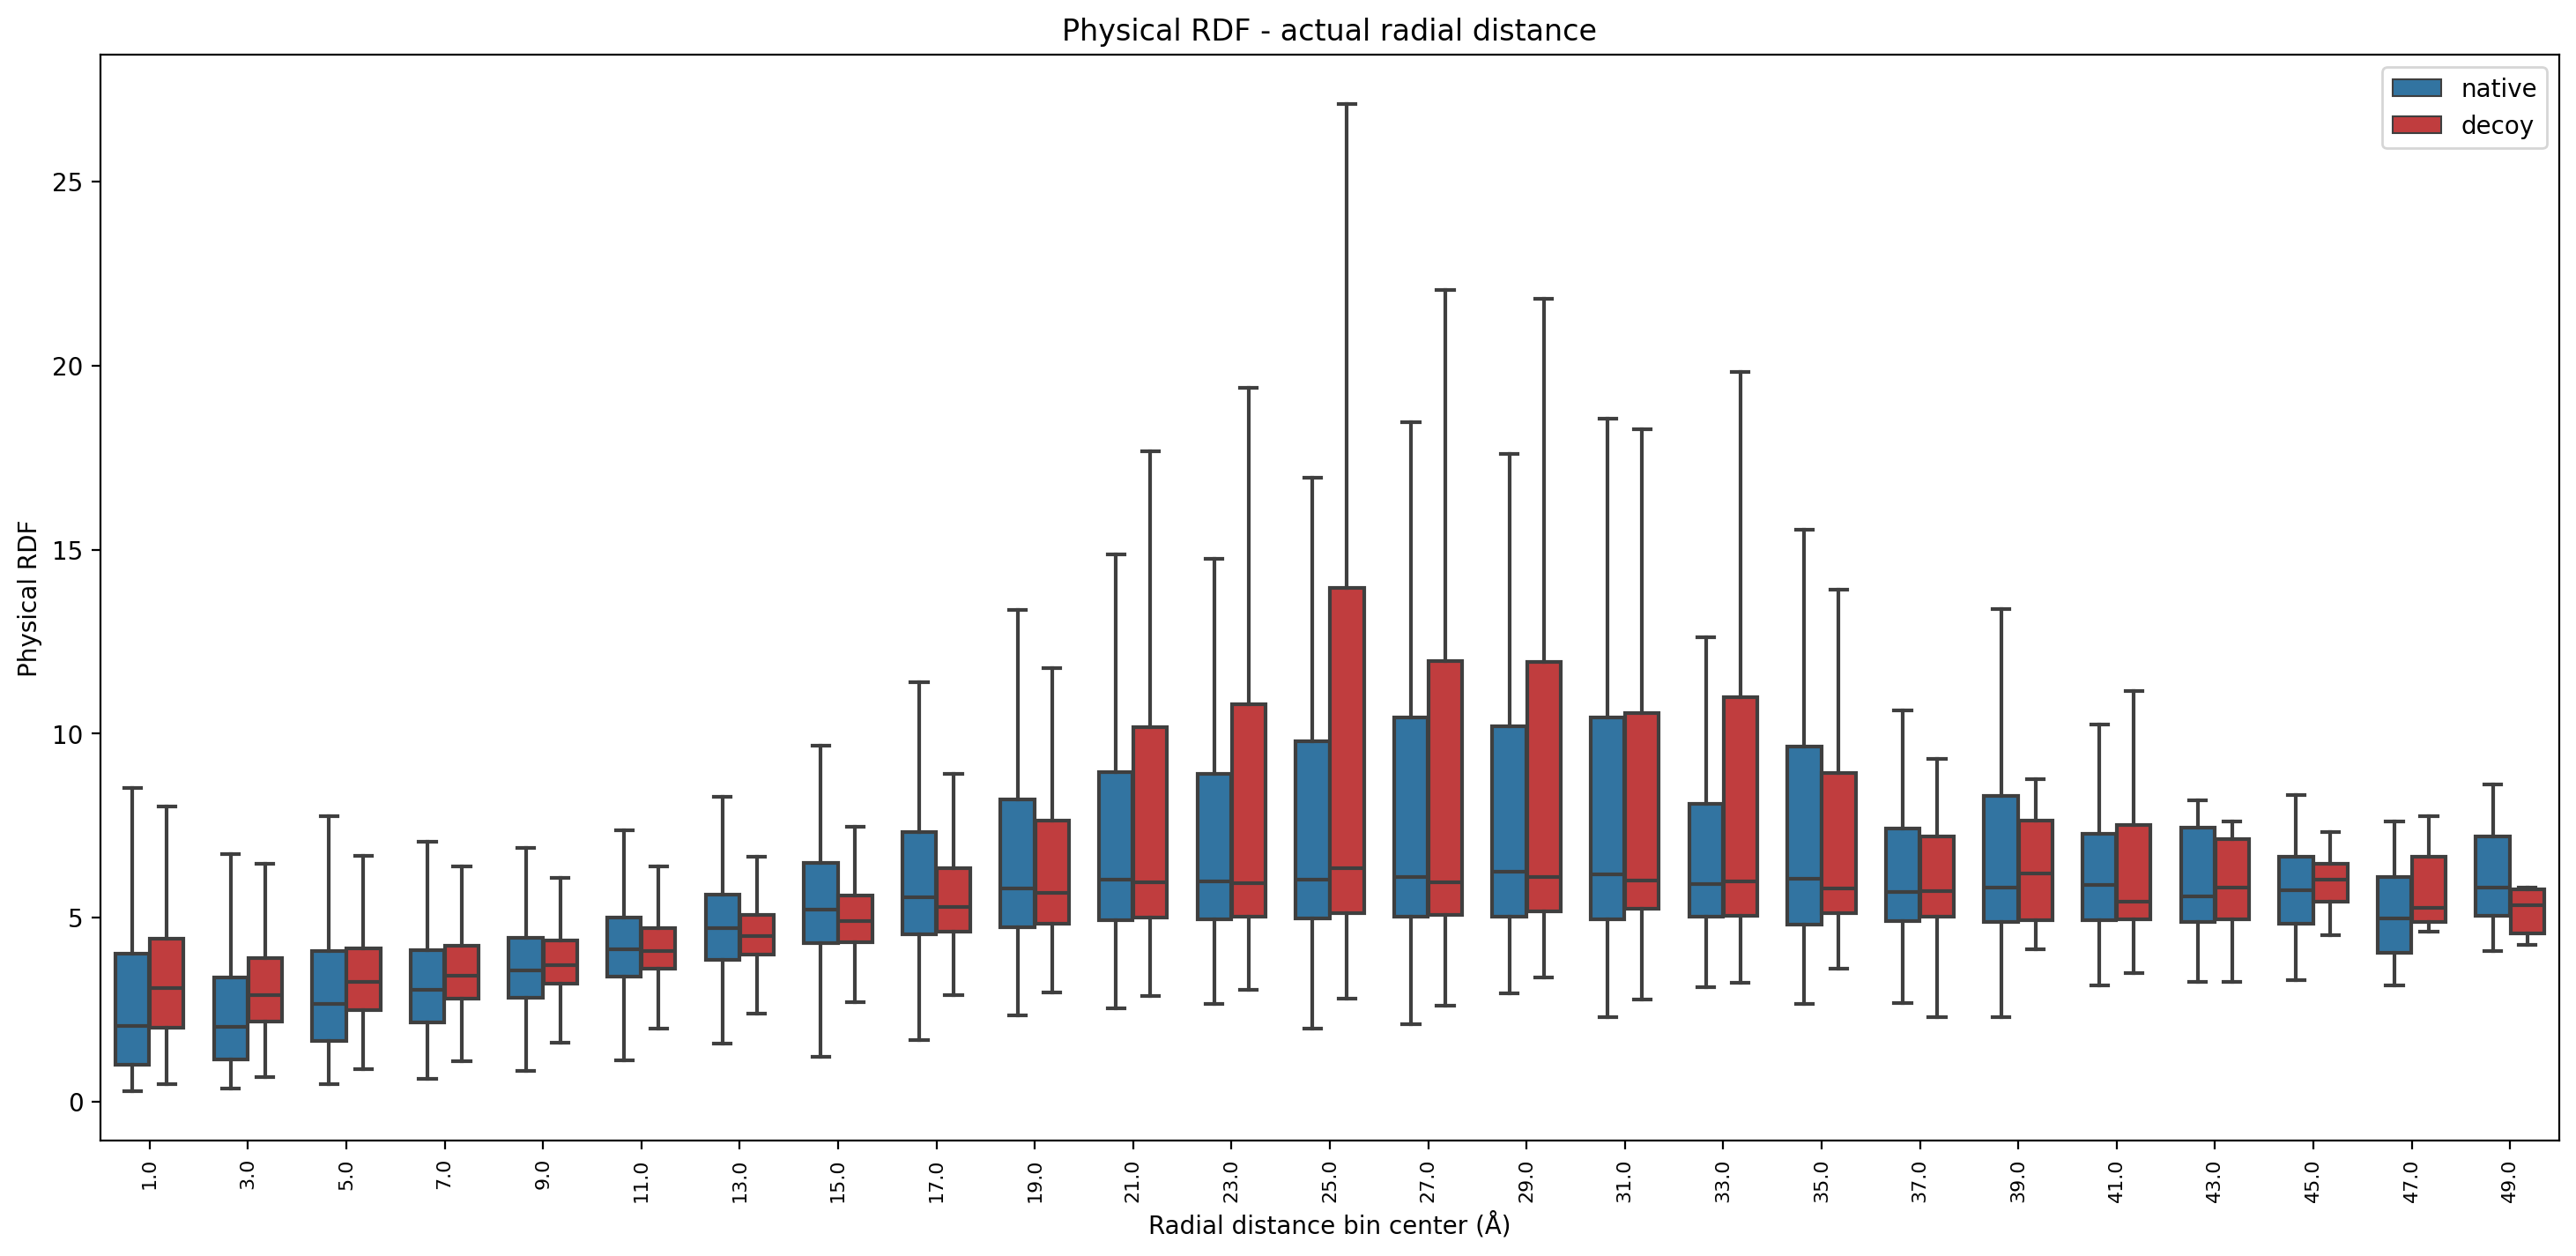

In [8]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=physical_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    showfliers=False,
    width=0.7,
    ax=ax,
)
ax.set_title('Physical RDF - actual radial distance')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Physical RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
plt.show()

A distanze centrali i decoys hanno distribuzioni ancora più estese dei native. A distanze basse o alte invece le distribuzioni dei decoys sono più compatte

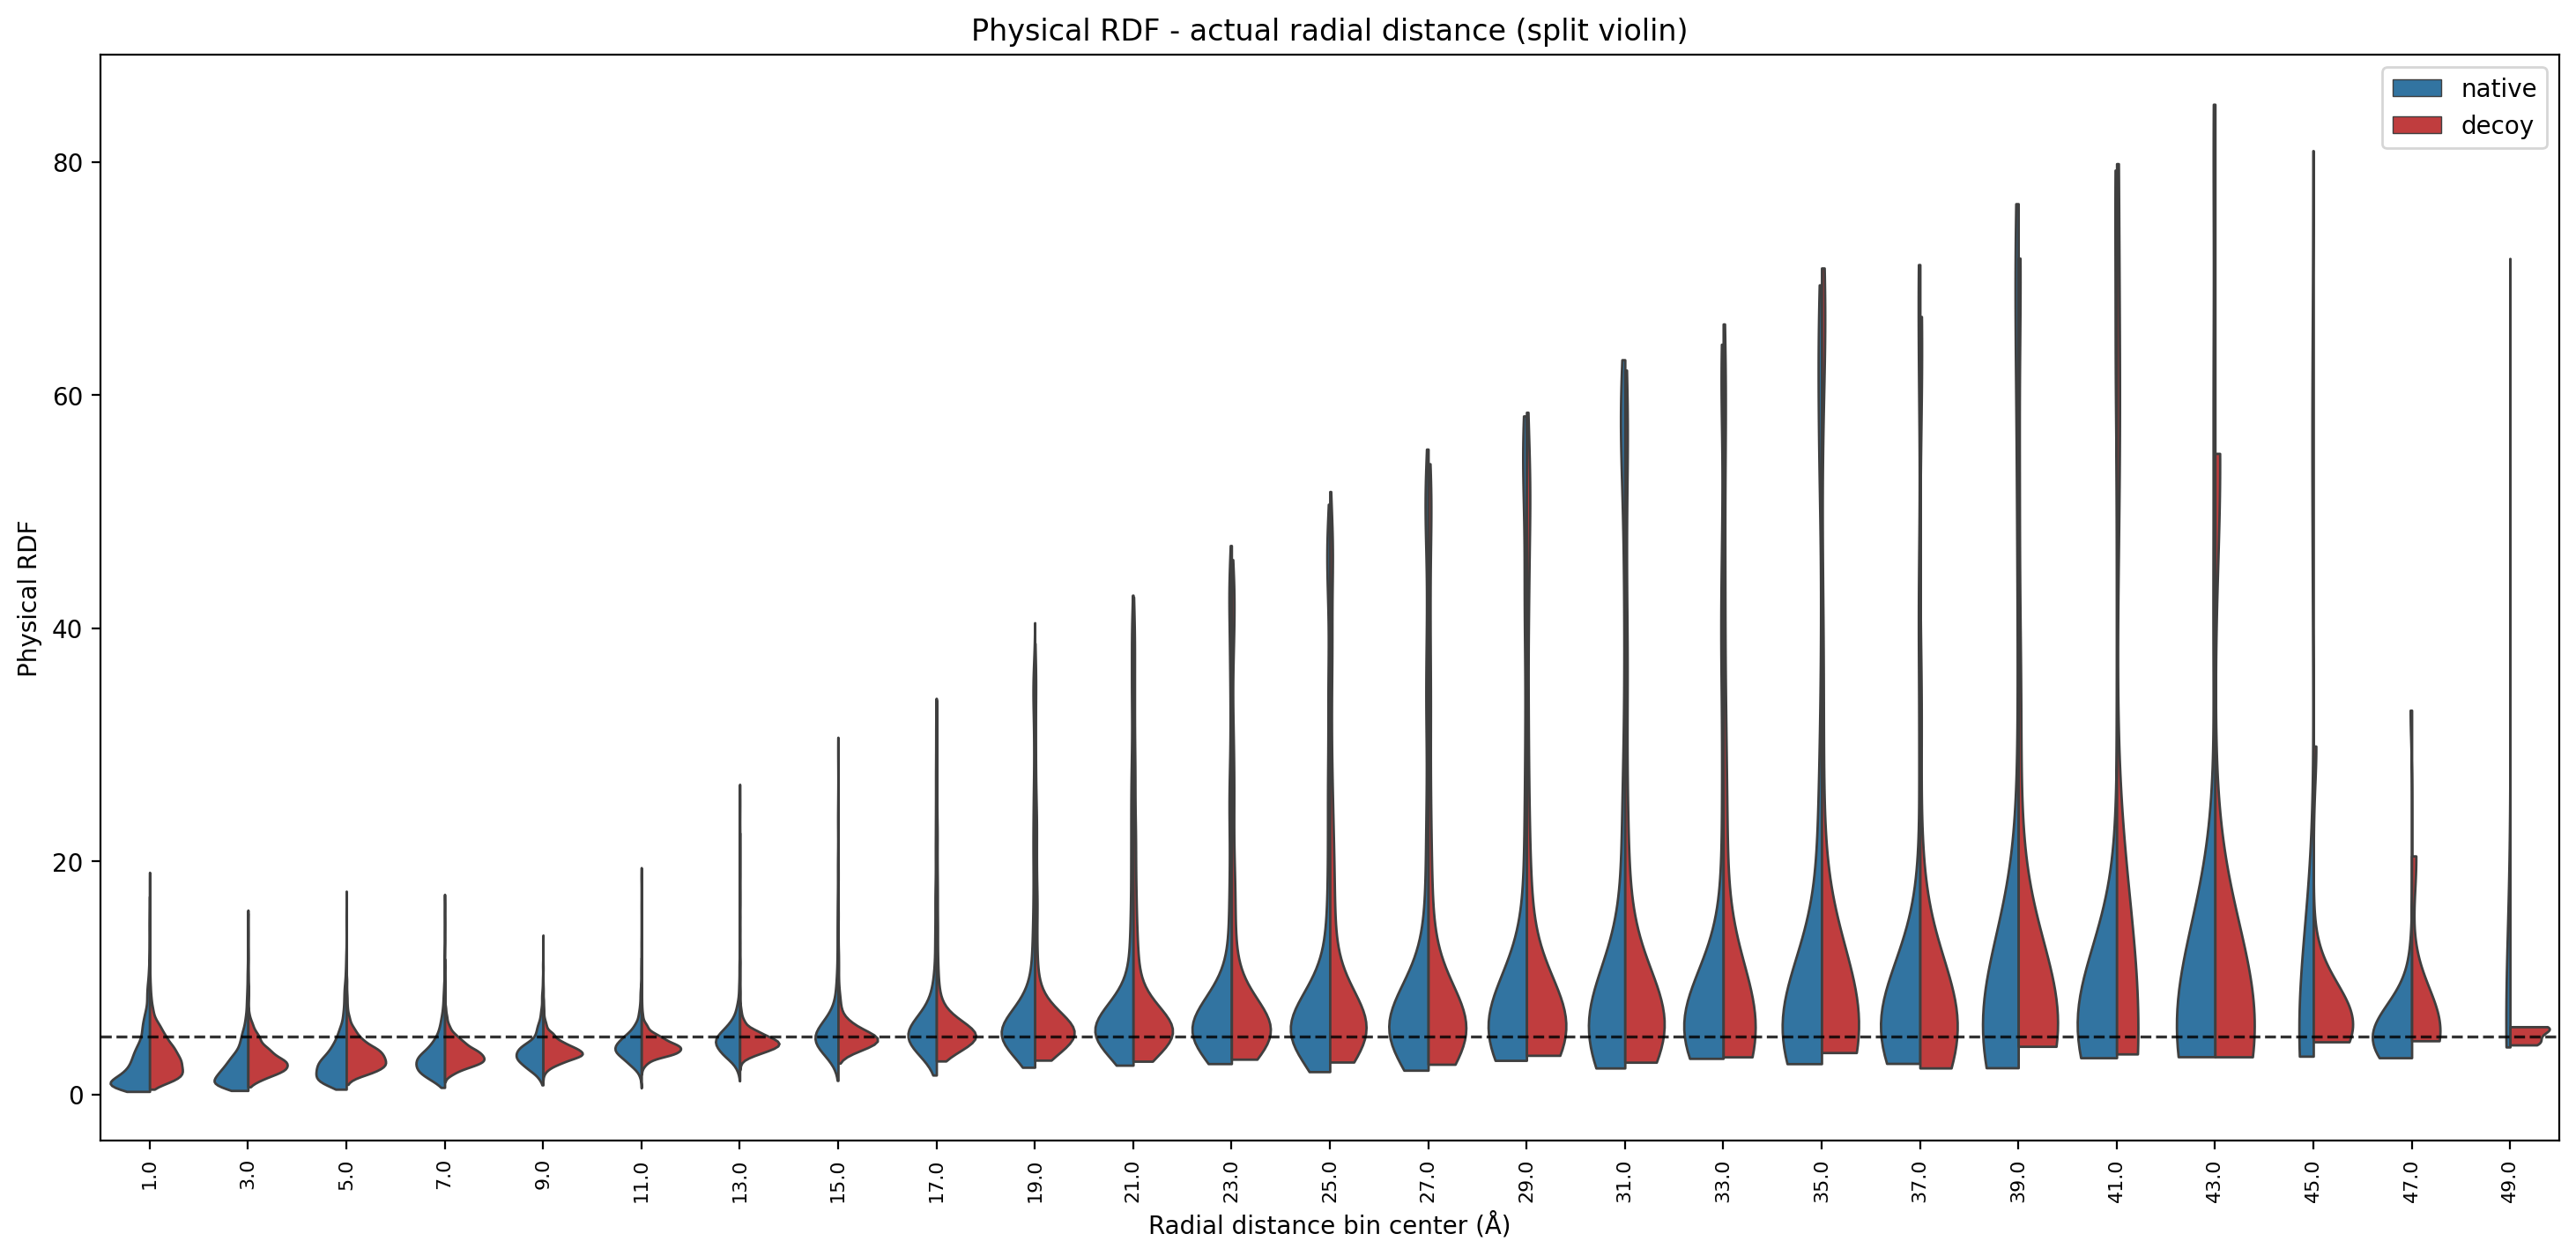

In [9]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.violinplot(
    data=physical_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    split=True,
    palette=palette,
    inner=None,
    cut=0,
    width=0.8,
    linewidth=1,
    ax=ax,
)
ax.axhline(5, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_title('Physical RDF - actual radial distance (split violin)')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Physical RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
plt.show()

## Zernike distance

### Raggio normalizzato

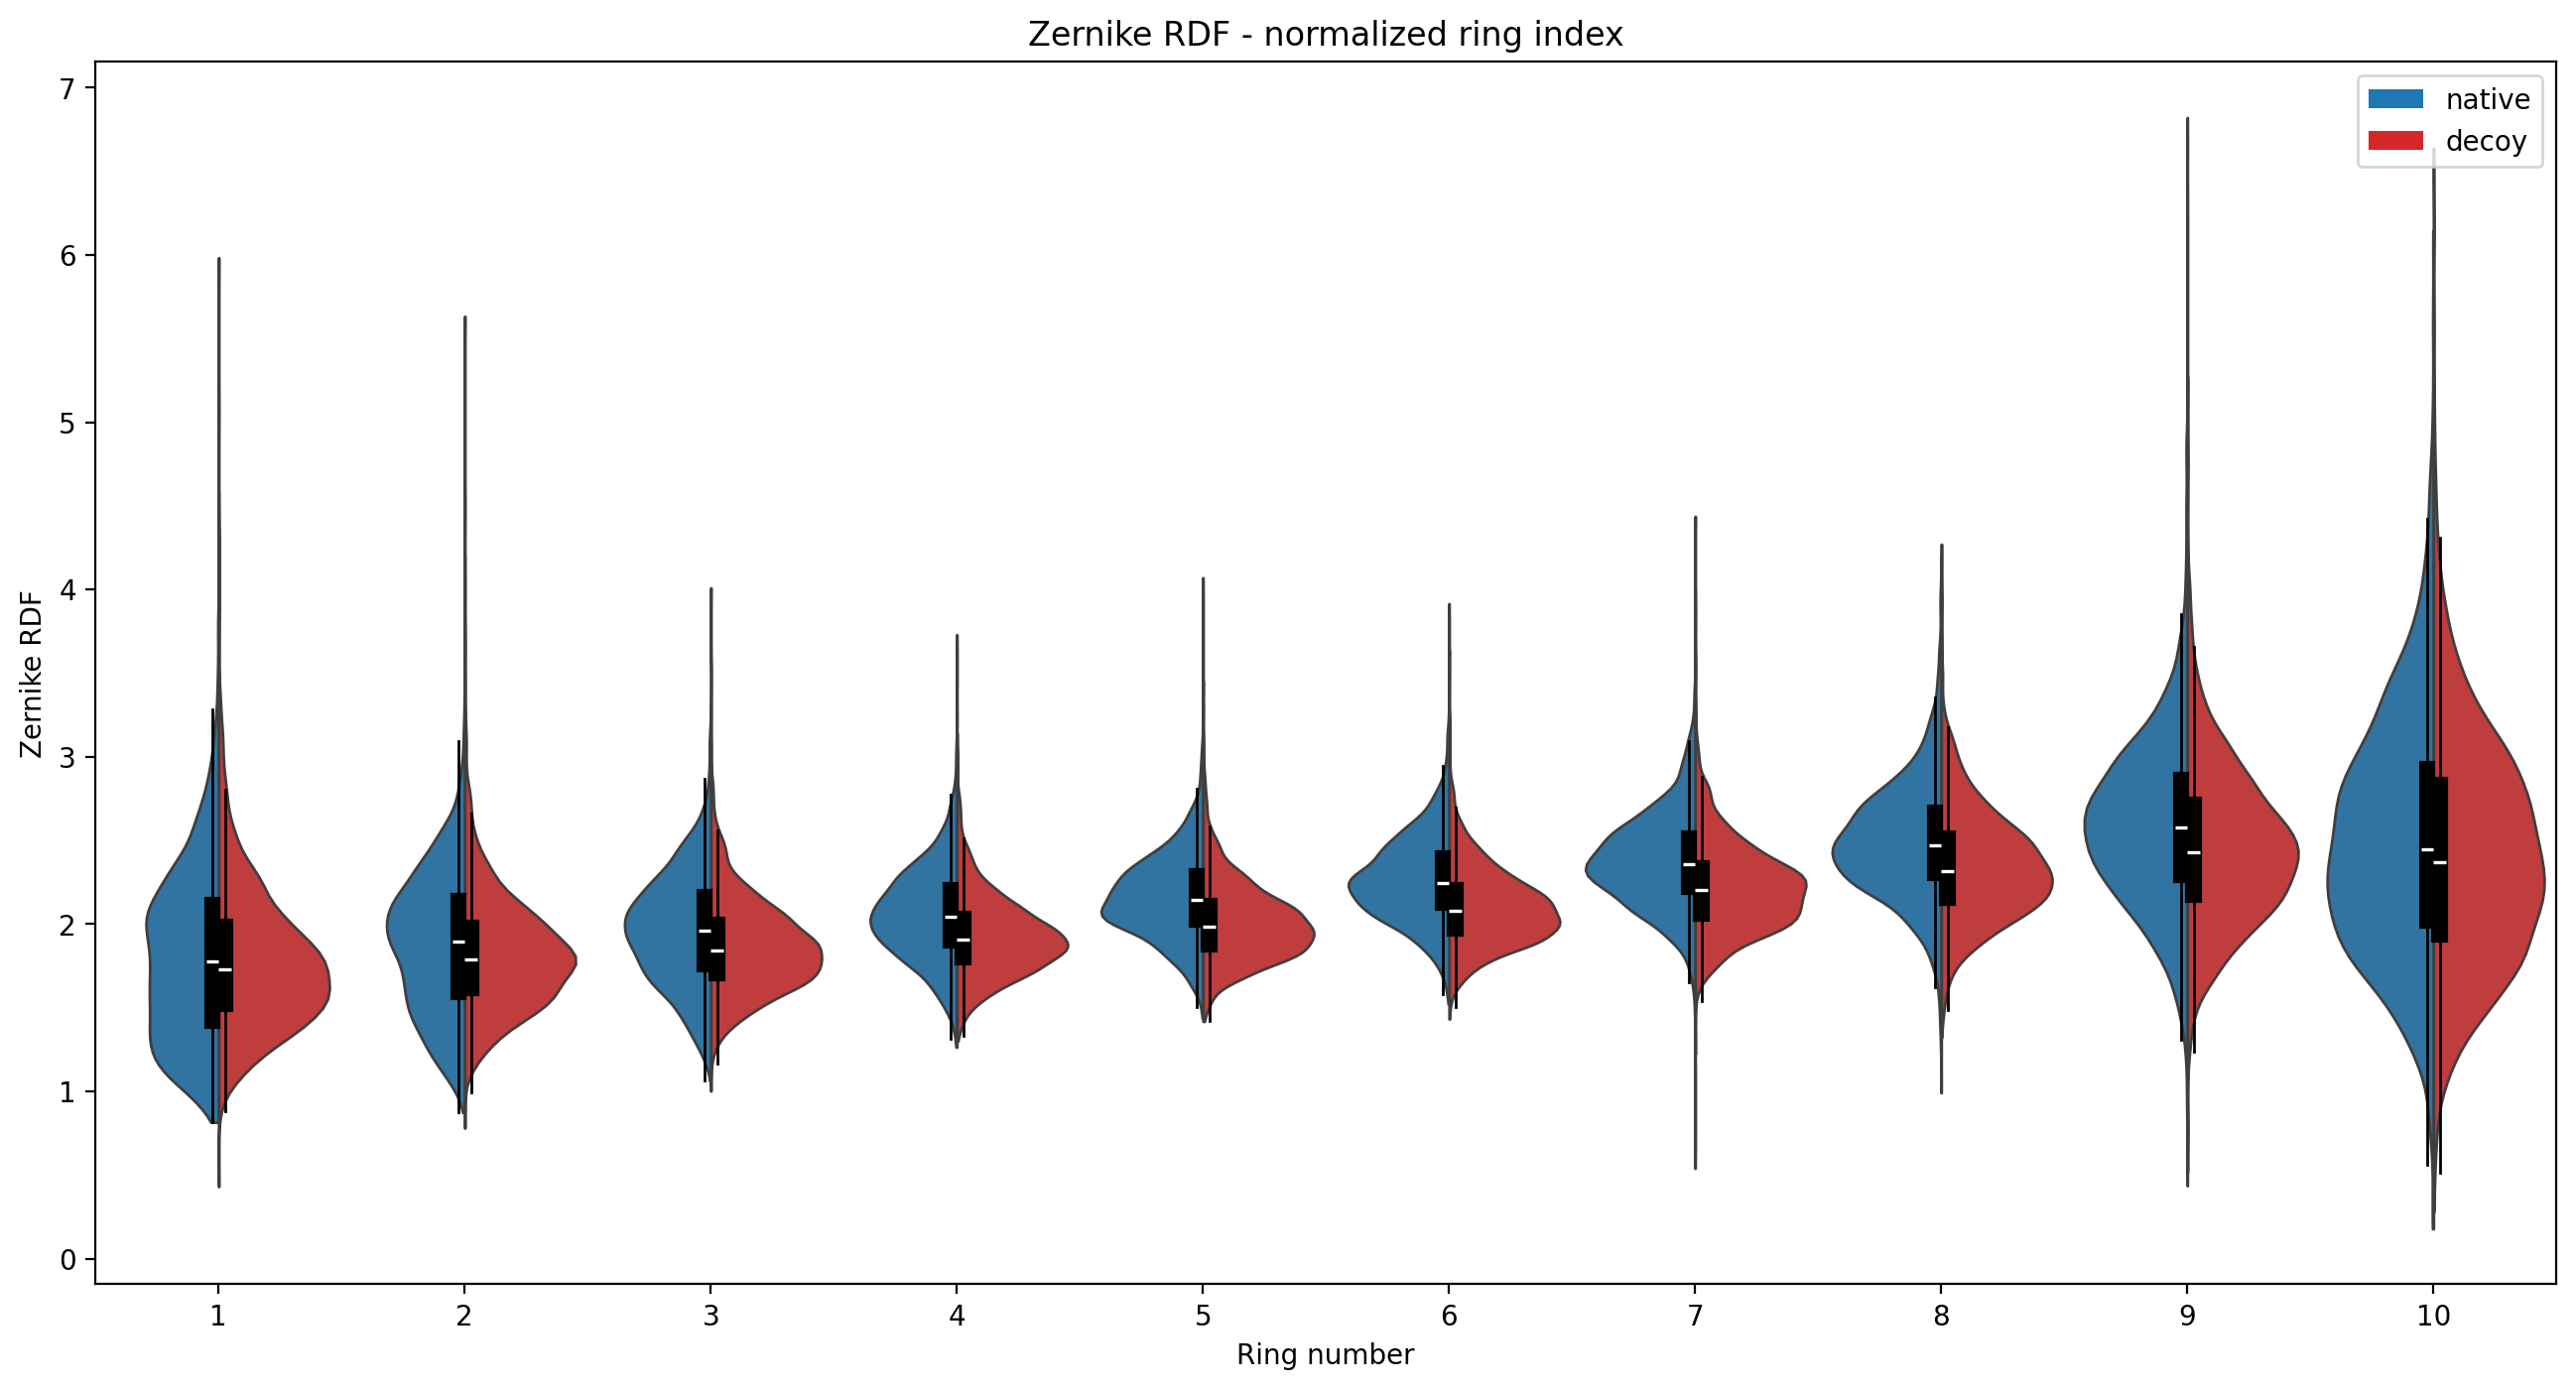

In [10]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(
    data=zernike_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    split=True,
    inner=None,
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
sns.boxplot(
    data=zernike_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    width=0.10,
    whis=1.5,
    showfliers=False,
    showcaps=False,
    boxprops={'facecolor': 'black', 'edgecolor': 'black', 'zorder': 3},
    whiskerprops={'color': 'black', 'linewidth': 1.0},
    capprops={'color': 'black', 'linewidth': 0.0},
    medianprops={'color': 'white', 'linewidth': 1.2, 'zorder': 5},
    ax=ax,
)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.legend(handles=[
    mpatches.Patch(facecolor=palette['native'], label='native'),
    mpatches.Patch(facecolor=palette['decoy'], label='decoy'),
], title='')
ax.set_title('Zernike RDF - normalized ring index')
ax.set_xlabel('Ring number')
ax.set_ylabel('Zernike RDF')
plt.show()

Nei primi due anelli le distribuzioni dei native sembrano quasi essere delle bimodali

### Raggio in angstrom

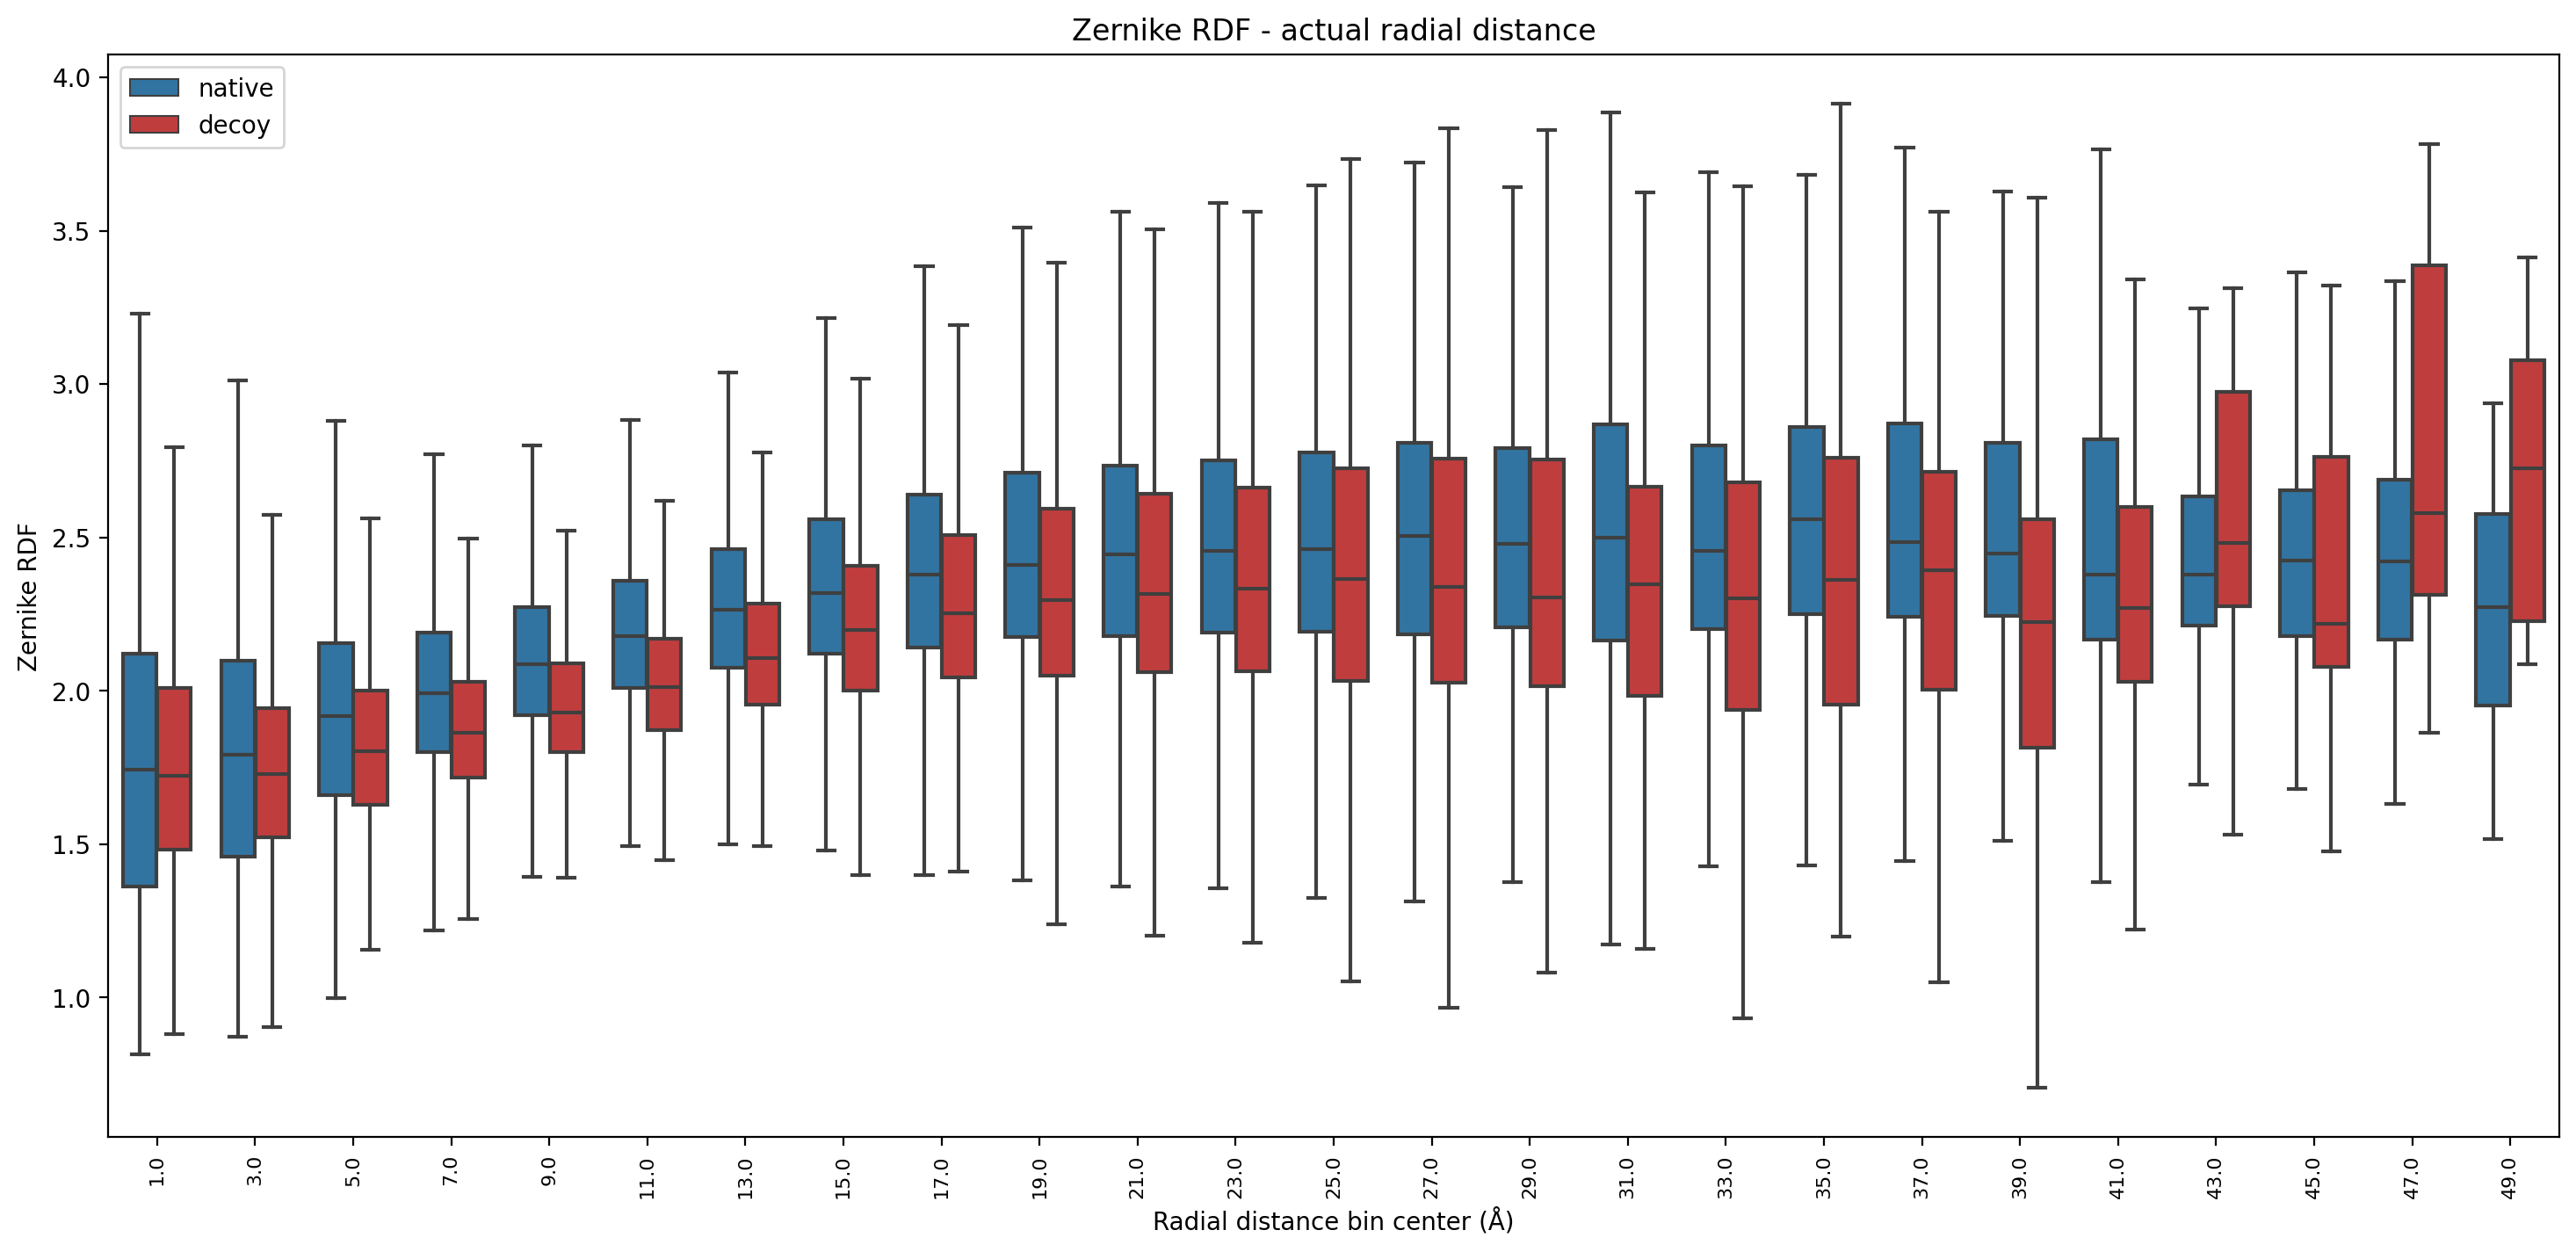

In [11]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=zernike_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    showfliers=False,
    width=0.7,
    ax=ax,
)
ax.set_title('Zernike RDF - actual radial distance')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Zernike RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
plt.show()

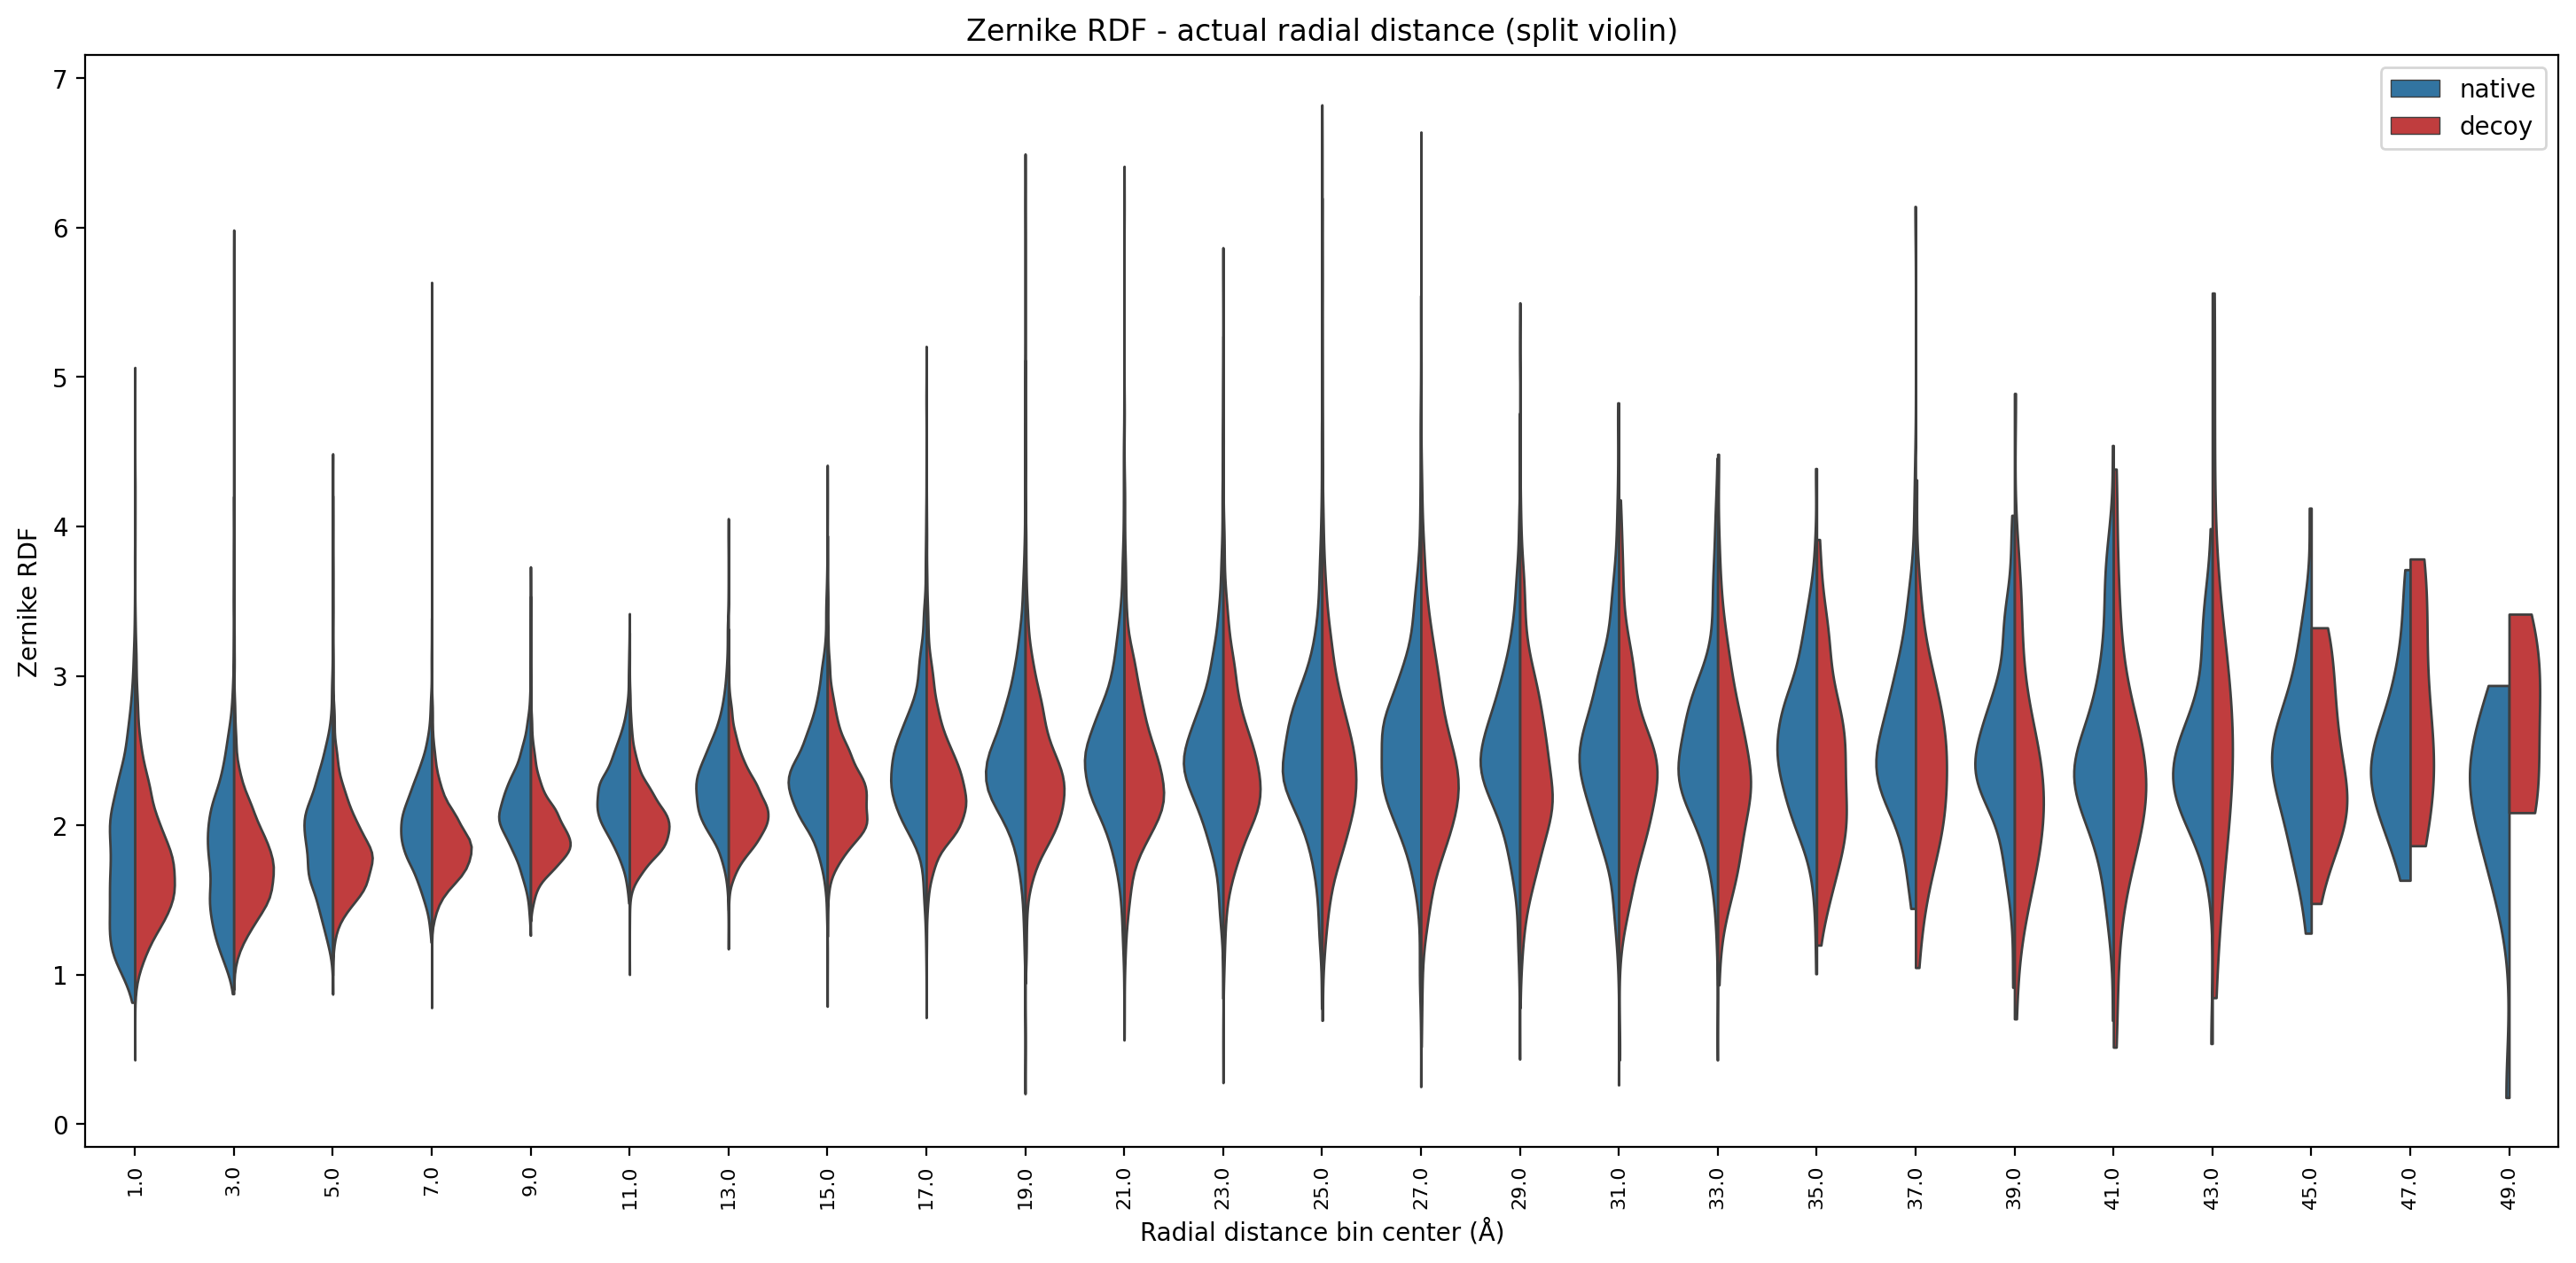

In [12]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.violinplot(
    data=zernike_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    split=True,
    palette=palette,
    inner=None,
    cut=0,
    width=0.8,
    linewidth=1,
    ax=ax,
)
ax.set_title('Zernike RDF - actual radial distance (split violin)')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Zernike RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
plt.show()

Negli ultimi bin le distribuzioni decoys tendono a distribuzioni uniformi. Forse indica che a quelle distanze gli algoritmi di docking smettono di ottimizzare l'energia e quindi sono come random patches, mentre i native no?

## Roughness

### Raggio normalizzato

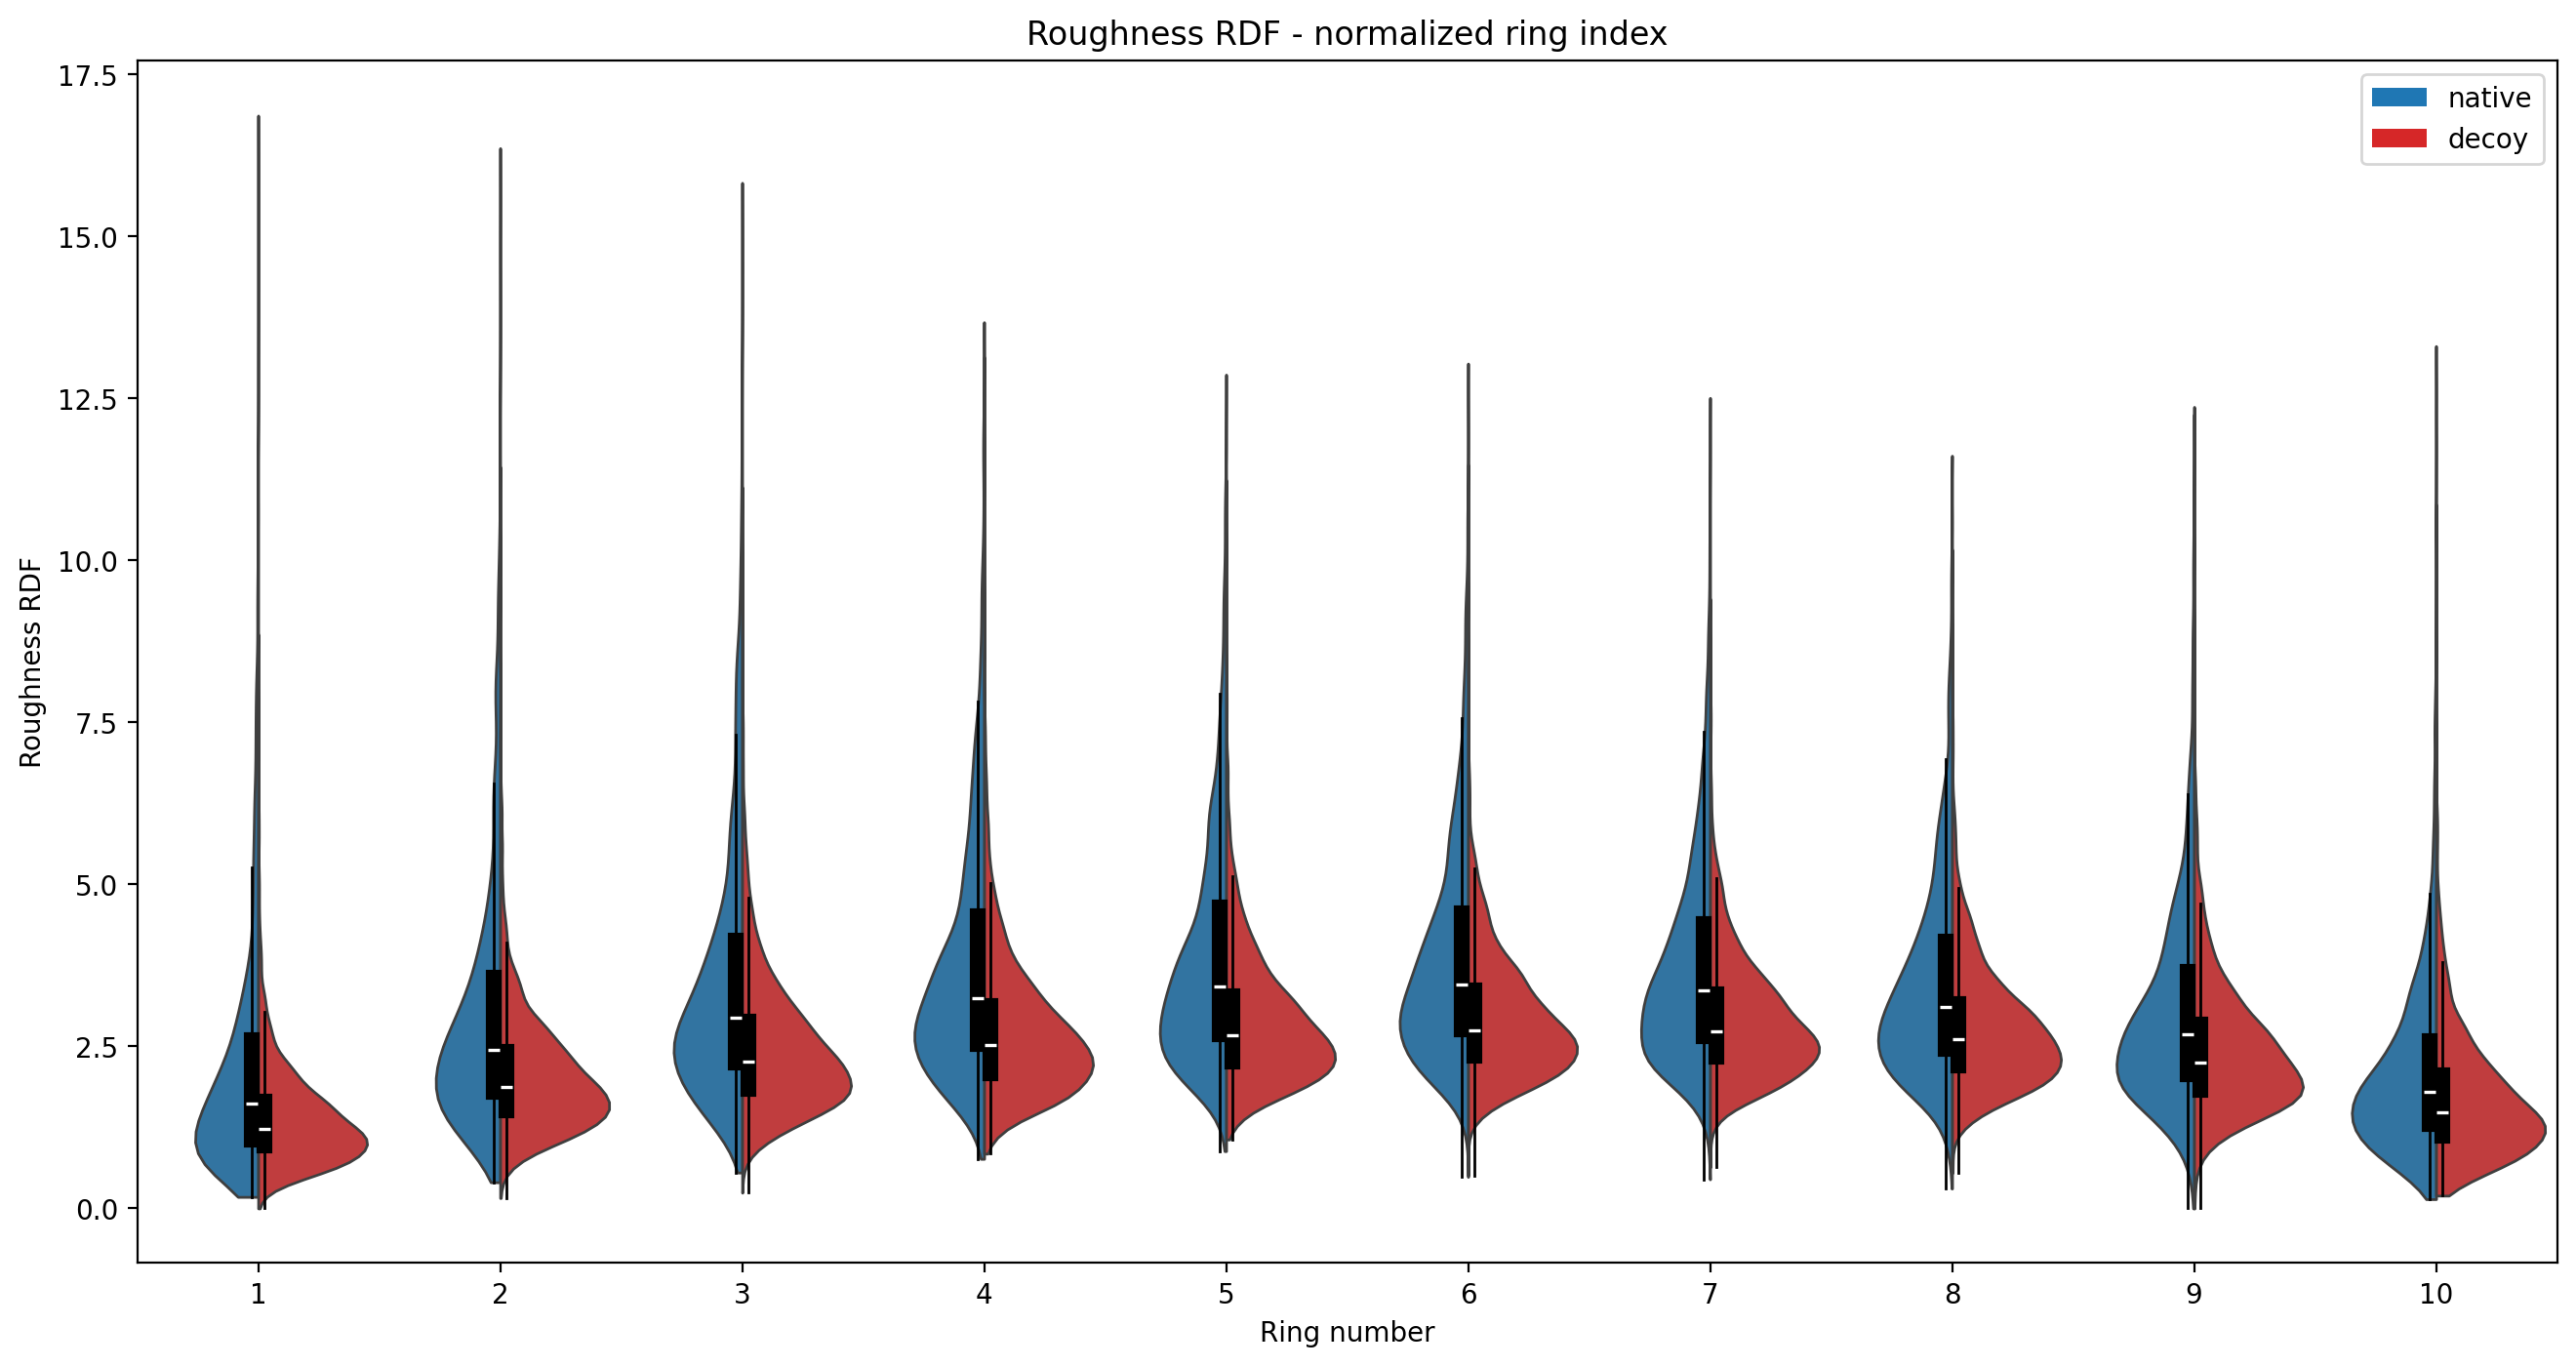

In [13]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.violinplot(
    data=roughness_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    split=True,
    inner=None,
    cut=0,
    width=0.9,
    linewidth=1,
    ax=ax,
)
sns.boxplot(
    data=roughness_plot_df,
    x='ring_id',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    width=0.10,
    whis=1.5,
    showfliers=False,
    showcaps=False,
    boxprops={'facecolor': 'black', 'edgecolor': 'black', 'zorder': 3},
    whiskerprops={'color': 'black', 'linewidth': 1.0},
    capprops={'color': 'black', 'linewidth': 0.0},
    medianprops={'color': 'white', 'linewidth': 1.2, 'zorder': 5},
    ax=ax,
)
legend = ax.get_legend()
if legend is not None:
    legend.remove()
ax.legend(handles=[
    mpatches.Patch(facecolor=palette['native'], label='native'),
    mpatches.Patch(facecolor=palette['decoy'], label='decoy'),
], title='')
ax.set_title('Roughness RDF - normalized ring index')
ax.set_xlabel('Ring number')
ax.set_ylabel('Roughness RDF')
plt.show()

### Raggio in angstrom

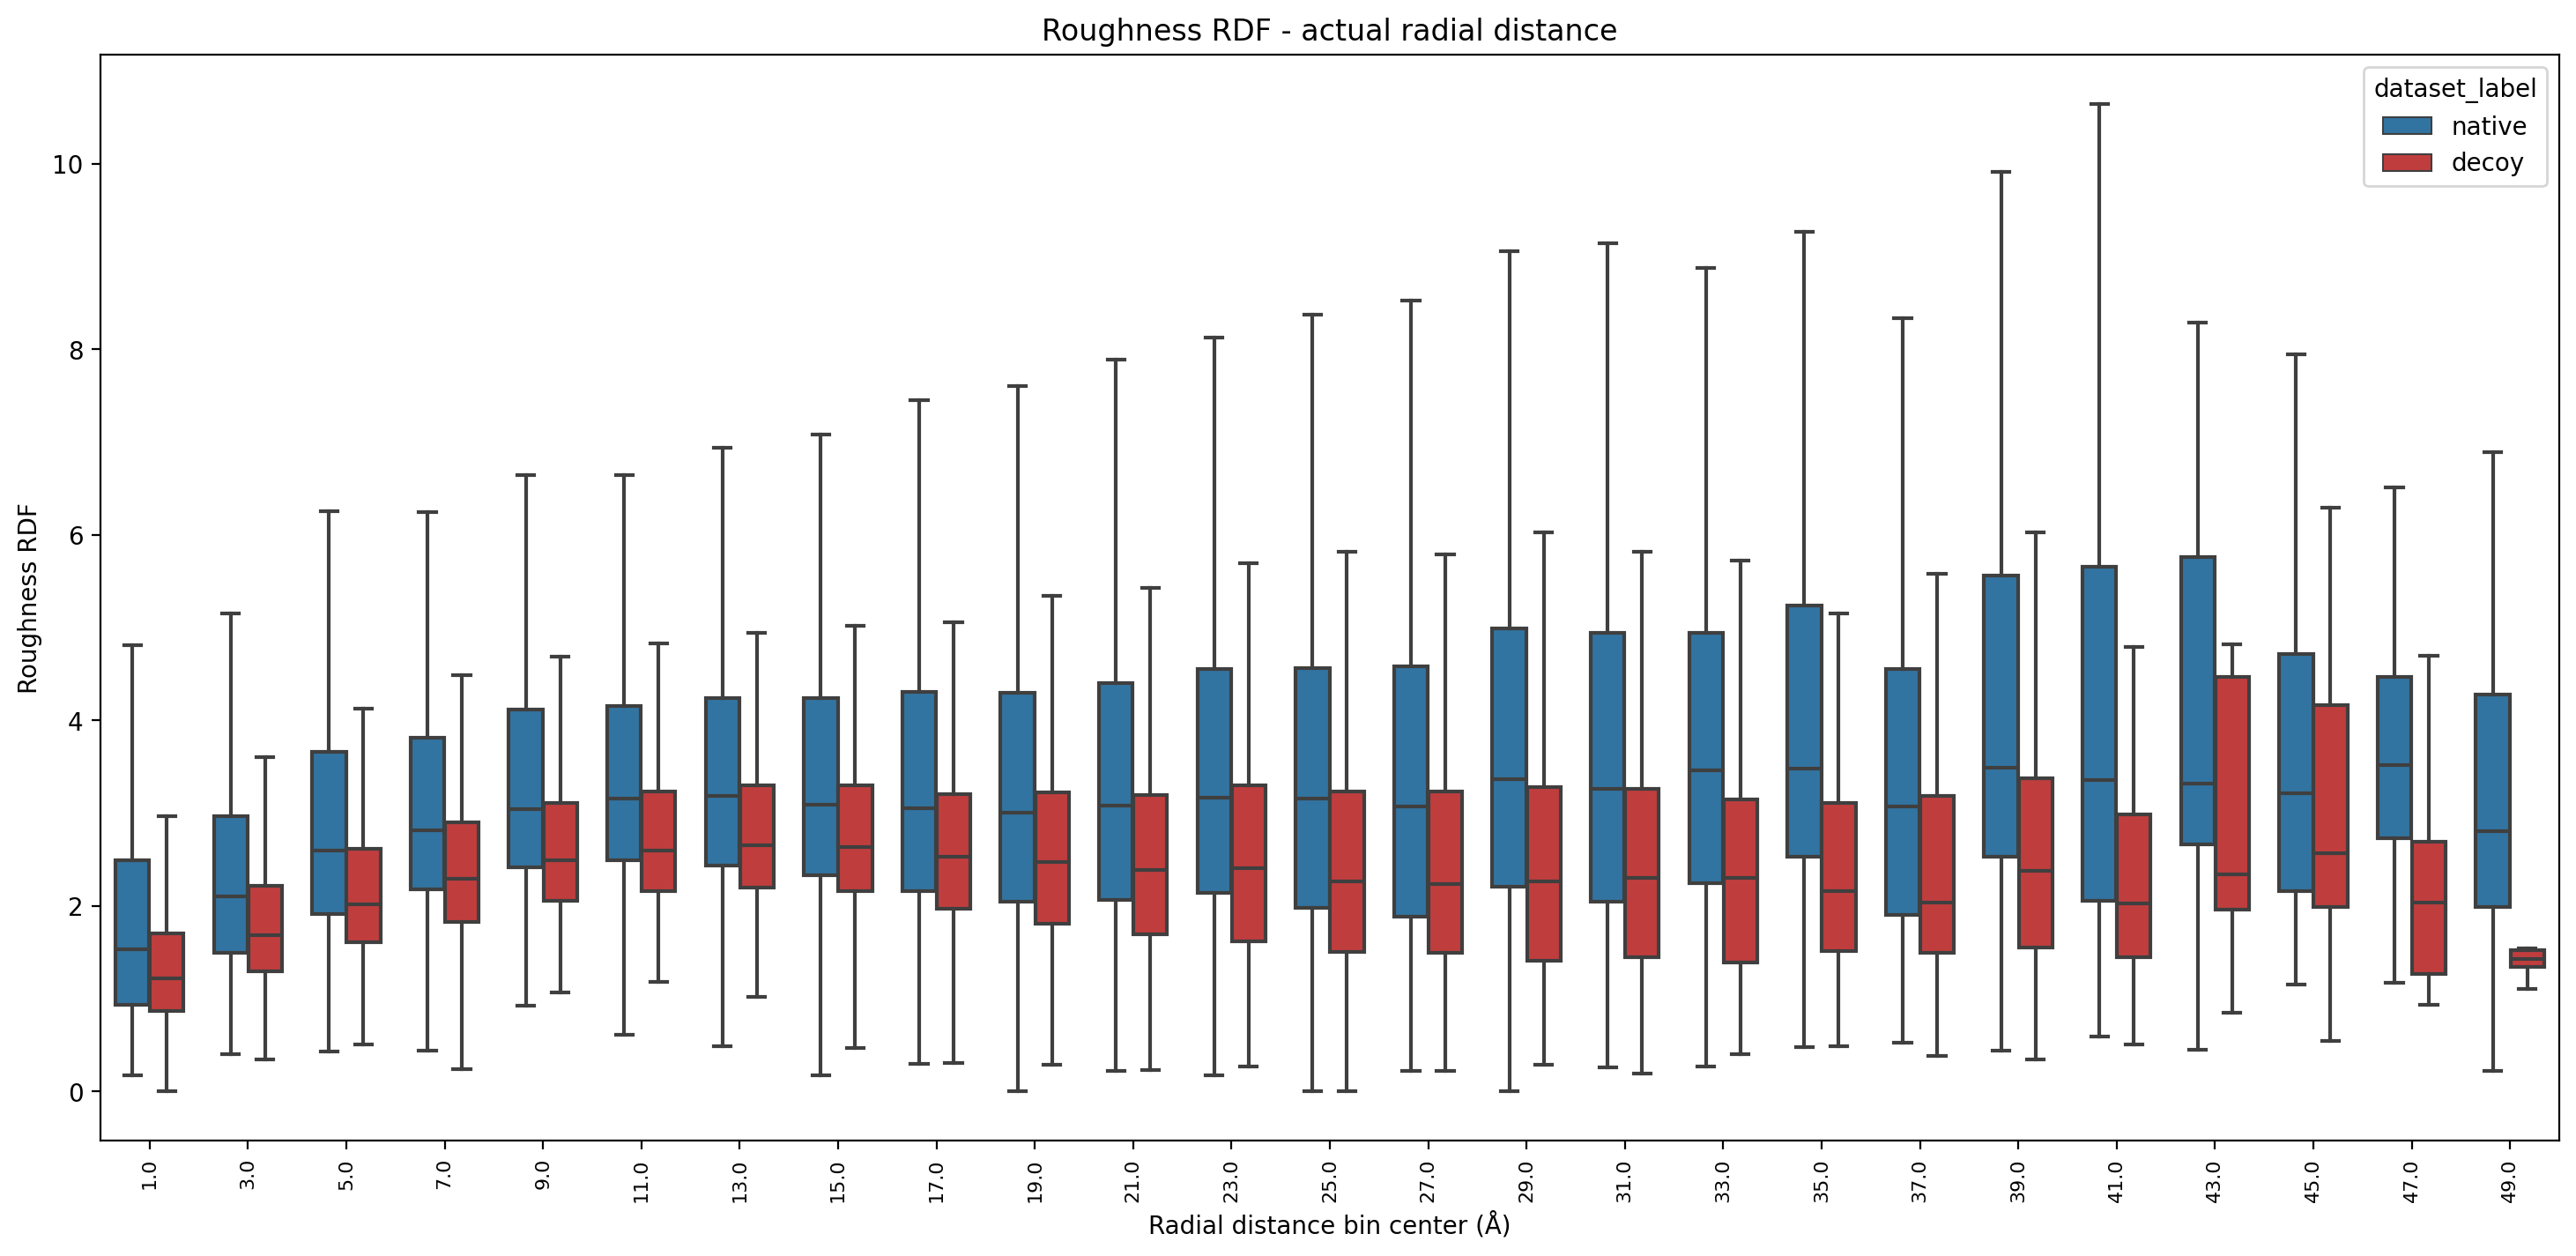

In [14]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.boxplot(
    data=roughness_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    palette=palette,
    dodge=True,
    showfliers=False,
    width=0.7,
    ax=ax,
)
ax.set_title('Roughness RDF - actual radial distance')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Roughness RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
plt.show()

I valori minimi di native e decoys sono simili, mentre i valori massimi dei native sono molto più alti, quindi hanno una coda più importante. I decoys hanno il 50% centrale della probabilità concentrato più in basso rispetto ai native

Forse è per queste code che l'andamento della RDF roughness plottato con la media per i decoys sembra uguale a quello dei native ma traslato verso il basso.

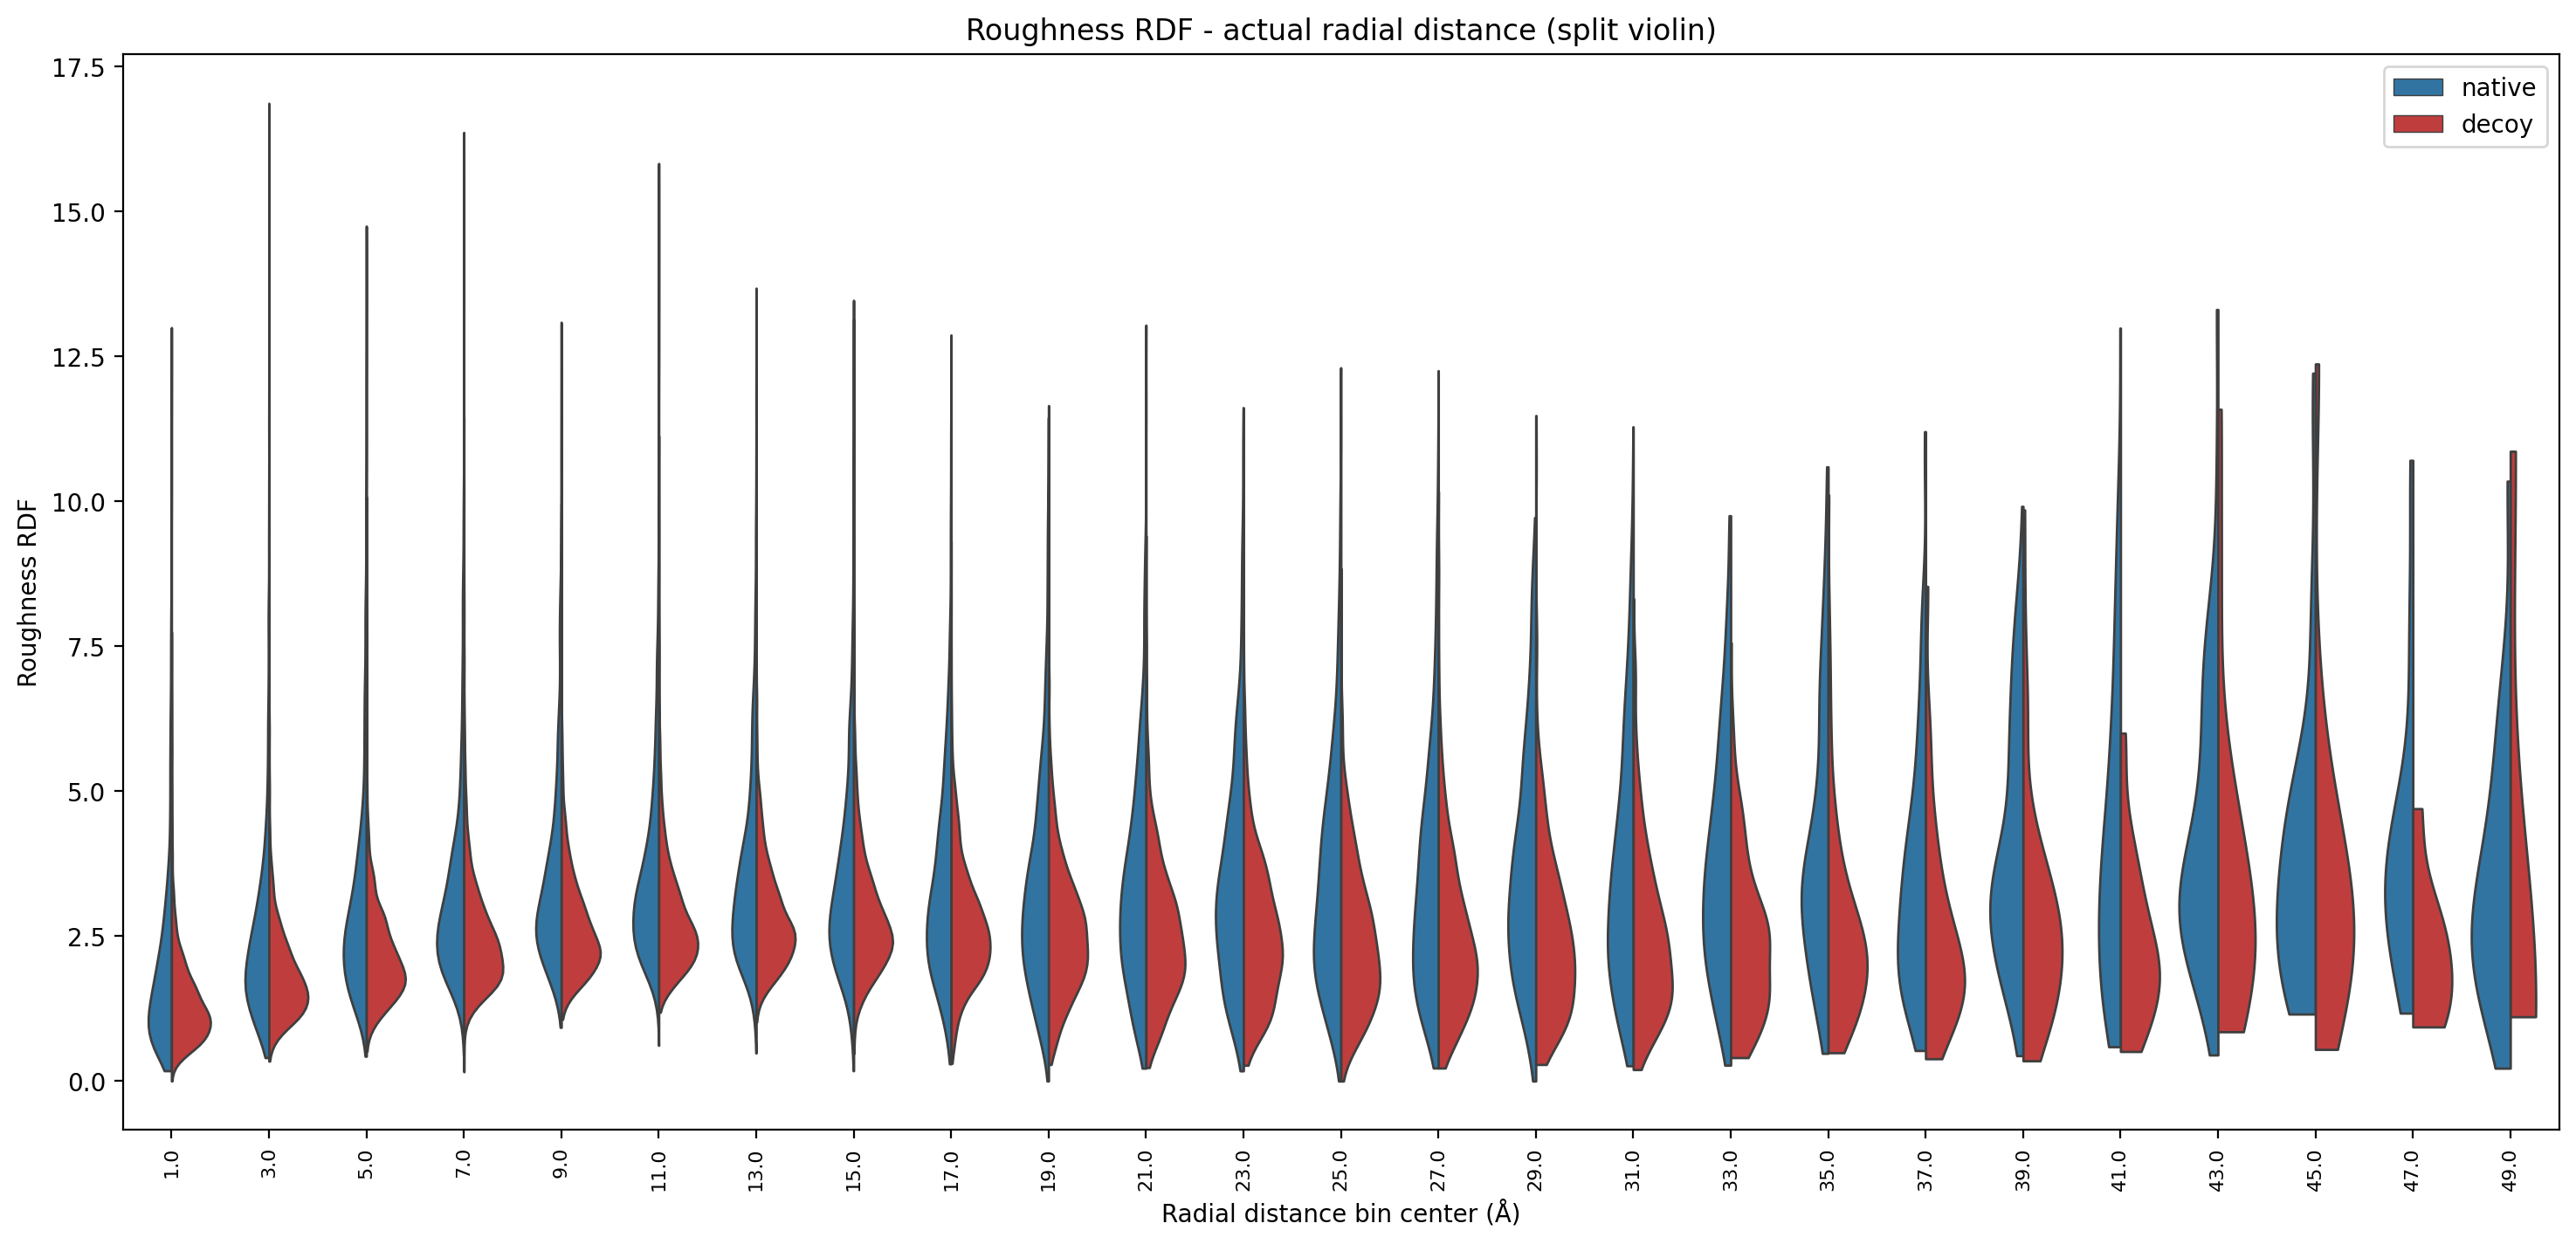

In [15]:
fig, ax = plt.subplots(figsize=(18, 8))
sns.violinplot(
    data=roughness_plot_df,
    x='radius_bin_center_A',
    y='rdf_value',
    hue='dataset_label',
    hue_order=['native', 'decoy'],
    split=True,
    palette=palette,
    inner=None,
    cut=0,
    width=0.8,
    linewidth=1,
    ax=ax,
)
ax.set_title('Roughness RDF - actual radial distance (split violin)')
ax.set_xlabel('Radial distance bin center (Å)')
ax.set_ylabel('Roughness RDF')
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.legend(title='')
plt.show()